> **Corrected version — patch notes**
> This notebook has been revised after a code review. Fixes applied:
> 1. **Embedding model/prefix mismatch (Section 9)** — the code was loading `MiniLM-L12-v2` while still using the E5-only `query:`/`passage:` prefix convention documented for `multilingual-e5-base`. Switched to **`bge-m3` served through Ollama** (not HuggingFace/`sentence-transformers` at all) — strong Arabic coverage, no prefix convention needed, and no more slow/stalled HuggingFace downloads since it's pulled via `ollama pull bge-m3`. The `sentence-transformers`/PyTorch dependency was dropped entirely as a result.
> 2. **Duplicate `build_strict_prompt` definition (old Section 20)** — a second definition was silently overriding the fully-specified Section 19 prompt. Removed; the useful new rule (no "positive/negative" sentiment classification) was merged into the single Section 19 prompt.
> 3. **Production `alpha` contradicted the notebook's own tuning results (Sections 13, 20)** — Section 11.1's sweep found `alpha=0.2` (lexical-favoring) performs best (MRR 0.805), but production defaulted to `alpha=0.6`. Defaults corrected; **re-run the alpha sweep after the embedding-model fix**, since the ranking may shift once semantic search is no longer handicapped.
> 4. **Section 20 markdown/code mismatch** — markdown promised a graceful no-API-key fallback; code called Ollama unconditionally with no error handling. Added a try/except fallback and corrected the markdown to describe the actual Ollama-based generation step.
> 5. Removed a stray local-debugging cell (`sys.executable`).
> 6. Added a caveat on the evaluation ground truth (keyword-substring relevance is a proxy, not verified relevance) and expanded the eval set.
> 7. Added a retriever-comparison chart and a final results-summary cell.
>
> **Because this environment does not have `herbal_book_ocr.txt`, the notebook has not been re-executed here.** Outputs from the pre-fix run have been kept only where they are still illustrative (e.g. the raw-ranking example in Section 14, which demonstrates a real, still-relevant phenomenon); all outputs downstream of the changed cells have been cleared and are marked `# TODO: re-run`. **Re-run the whole notebook top-to-bottom with the data file present to regenerate all outputs before presenting it.**


> **Adapted to a new dataset (this revision)**
> This notebook was originally built around `herbal_book_ocr.txt`, a scanned/OCR'd ~400-page book with
> `### Page N` markers. It has been adapted here to run on **`herbs_encyclopedia.txt`**, a clean, typed
> Arabic reference of **100 herb/plant entries**, each with the same five fields (benefits, conditions
> treated, usage, warnings, price). Changes made throughout the notebook:
> 1. **Section 3 (data loading)** — rewritten to split on the `📌 N.` entry marker instead of OCR page
>    markers; one "page" now equals one herb entry (no real pagination exists in this source).
> 2. **Section 5 (chunking)** — unchanged code, but since every entry is short, it now yields exactly one
>    chunk per herb rather than multiple overlapping windows.
> 3. **Section 12** — the old `CONTENT` / `REFERENCE_ONLY` heuristic doesn't apply (this corpus has no
>    bibliography-pointer chunks), so it was repurposed into a `HIGH_RISK` / `STANDARD` safety flag for
>    entries whose warning field names a severe or life-threatening risk (16 of the 100 entries).
>    Everywhere that used to demote `REFERENCE_ONLY` now instead *prioritizes* `HIGH_RISK`, in the context
>    package sort and in the strict prompt's rules.
> 4. **Sections 14–15, 19, 21–23** — the worked examples (`الرازيانج`/fennel, "see also" pointers) were
>    swapped for real cases from this corpus (`الحرمل`/harmal as the `HIGH_RISK` example; the السرطان
>    query as a genuine no-information refusal case, since this corpus never mentions cancer treatment).
> 5. **Section 22** — the OCR-specific noise discussion was marked as not applicable to this clean source.
>
> Sections 3–8 and 12–15 (everything not dependent on a running Ollama server) were executed against the
> real `herbs_encyclopedia.txt` while making these edits and run without errors. Sections 9, 16, and
> 20–21 need a local Ollama server (`ollama pull bge-m3` and `ollama pull 0ssamaak0/silma-v1`) to actually
> run — see Section 23 for the full list.


# Arabic Herbal-Medicine RAG System
## From "Lab 6" lexical retrieval, "Lab 7" semantic retrieval, to "Lab 8" full-pipeline RAG engineering

Lab 6 built lexical retrieval (Bag-of-Words, TF-IDF, BM25) over a small **English** knowledge base.
Lab 7 added **dense embeddings**, cosine similarity, hybrid lexical+semantic retrieval, FAISS indexing,
and a discipline of *evaluating and breaking* retrievers before ever generating an answer. Lab 8 goes one
layer further: retrieval alone is not the pipeline — a **context package** (filtering, deduplication,
currency/quality preference, a word budget) sits between retrieval and the prompt, and the **prompt
itself** is an engineered artifact with its own failure modes, not just "stuff the context in and ask."

This notebook carries all three forward onto a real, messy, OCR'd **Arabic** source —
`herbal_book_ocr.txt`, a scanned book of traditional herbal remedies (الطب المجرب والتداوي بالأعشاب) —
and builds it into a working RAG system:

```text
Raw OCR text (Arabic)
→ page-aware ingestion
→ Arabic-specific normalization & cleaning
→ dual preprocessing (light-clean for embeddings, stemmed/stopword-free for lexical search)
→ sentence-aware chunking with overlap
→ TWO lexical baselines (TF-IDF, BM25) + dense embeddings (multilingual sentence-transformer) + FAISS
→ TWO hybrid fusion strategies (Reciprocal Rank Fusion, alpha-weighted score fusion) + an alpha sweep
→ retrieval evaluation (Precision@K, Recall@K, Hit Rate@K, MRR) across every retriever, side by side
→ CONTENT vs. REFERENCE_ONLY chunk classification (this book's analogue of "current vs. outdated")
→ a context package: score floors, dedup, per-page cap, word budget, quality-preferring sort
→ a four-layer failure taxonomy (retrieval / context / prompt / generation)
→ Arabic-specific embedding failure-case analysis (quantities, references, negation, rare terms)
→ final error analysis on the failed queries
→ three prompt styles (weak / better / strict) evaluated against the same prompt anatomy
→ grounded answer generation: context package + strict prompt, with an anti-hallucination guarantee
```

**Why Arabic needs its own pipeline, not just "Lab 6/7/8 in Arabic":**

- Arabic is written right-to-left, is *morphologically rich* (a single root can generate dozens of
  surface forms via prefixes/suffixes/infixes), and commonly appears **without diacritics (tashkeel)**
  in real text — while OCR sources sometimes *do* include stray diacritics that need stripping.
- The same letter can be written in multiple visually-different forms that are semantically identical
  (أ / إ / آ / ا, or ة / ه, or ى / ي). Untreated, a vectorizer would treat `الأعشاب` and `الاعشاب` as two
  different words, silently fragmenting the vocabulary.
- OCR of Arabic is noisy: page numbers, publisher boilerplate, reversed/garbled Latin fragments, and
  form-feed characters are mixed into the real content and must be filtered before indexing.
- Off-the-shelf English stopword lists and stemmers (NLTK's default) do not cover Arabic — dedicated
  resources (`pyarabic`, `arabic-stopwords`, `tashaphyne`/Farasa-style light stemmers) are required.


## Table of contents
1. Install dependencies
2. Imports
3. Data loading & ingestion
4. Advanced Arabic text preprocessing
5. Text chunking with overlap
6. What is an embedding? Sparse vs. dense vectors
7. Lexical baseline 1: TF-IDF
8. Lexical baseline 2: BM25
9. Dense embeddings & FAISS vector store
10. Hybrid retrieval, two ways (RRF / alpha fusion)
11. Retrieval evaluation (+ alpha sweep, + comparison chart)
12. Content vs. reference-only chunk classification
13. Build a context package
14. Inspect context packages, and a content-vs-reference-only conflict
15. Context failure analysis (four-layer taxonomy)
16. Arabic-domain embedding failure cases
17. Final error analysis
18. Prompt anatomy
19. Three prompt styles
20. Grounded generation: context package + strict prompt
21. End-to-end demo across several queries
22. Notes on what makes Arabic retrieval harder than English
23. Results summary


## Section 1 — Install dependencies

- `pyarabic` — Arabic normalization, diacritics/tatweel stripping, tokenization helpers.
- `arabic-stopwords` — a maintained Arabic stopword list (far larger and more accurate than ad-hoc lists).
- `tashaphyne` — a light Arabic stemmer (prefix/suffix stripping), similar in spirit to a Farasa/ISRI light stemmer.
- `rank_bm25` — the same BM25 implementation used in Lab 6, reused here for Arabic lexical retrieval.
- `faiss-cpu` — vector similarity search / vector store.
- `requests` — used to call the local Ollama server's `/api/embed` endpoint for embeddings, and
  `ollama` (Python client) for generation in Section 20. Embeddings no longer go through
  `sentence-transformers`/HuggingFace at all — this drops the heavy PyTorch install.

Run this cell once. `%%capture` keeps the log quiet; remove it if you need to debug an install.


In [1]:
%%capture
%pip install -q pyarabic arabic-stopwords tashaphyne rank_bm25 faiss-cpu requests ollama


## Section 2 — Imports

Same shape as Lab 6/7 (`re`, `numpy`, `pandas`, `sklearn`, `rank_bm25`, `faiss`) plus the Arabic-specific
additions. No `sentence-transformers` import — dense embeddings are called through Ollama's HTTP API
(`requests`) in Section 9 instead.


In [2]:
import re
import json
import math
import numpy as np
import pandas as pd

import pyarabic.araby as araby
import arabicstopwords.arabicstopwords as arabicstopwords
from tashaphyne.stemming import ArabicLightStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from rank_bm25 import BM25Okapi
import faiss

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_columns", 120)


## Section 3 — Data loading & ingestion

**Adapted for the new source.** This notebook now runs on `herbs_encyclopedia.txt` — a clean,
already-typed (not scanned/OCR'd) Arabic reference of 100 herb/plant entries, each formatted the same
way:

```
📌 12. الشومر / الشمر (Fennel)
   • الفوائد الرئيسية: ...
   • الأمراض التي تعالجها: ...
   • طريقة الاستخدام: ...
   • التحذيرات والموانع: ⚠️ ...
   • السعر الاسترشادي (لكل 100 جرام): ...
------------------------------------------------------------
```

There are no `### Page N` markers or `\x0c` form-feed characters here — this isn't OCR output — so we
split on the `📌 N.` marker that starts every entry instead. We keep the variable names `raw_pages` /
`page` from the original pipeline for compatibility with every later section (chunking, per-page caps,
citations, etc.); here, one "page" is simply one herb entry (`page` = the entry's number, 1–100), since
this source has no real pagination to key off.

We still read the file explicitly as UTF-8 (Arabic text corrupts silently under the wrong encoding, e.g.
if a tool defaults to `cp1252` or `latin-1`).


In [ ]:
DATA_PATH = r"C:\Users\Admin\Desktop\333\herbs_encyclopedia.txt"   # rename/upload the encyclopedia .txt to this name, or edit this path

with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw_text = f.read()

print(f"Loaded {len(raw_text):,} characters")

# Every entry starts with '📌 N. <name>'. We split on that marker and take everything up to the next
# marker (or end of file) as the entry body — this replaces the old '### Page N' OCR-page splitter.
entry_pattern = re.compile(r'📌\s*(\d+)\.\s*(.+)')
matches = list(entry_pattern.finditer(raw_text))

raw_pages = []
for i, m in enumerate(matches):
    herb_id = int(m.group(1))
    herb_name = m.group(2).strip()
    start = m.end()
    end = matches[i + 1].start() if i + 1 < len(matches) else len(raw_text)
    body = re.sub(r'-{5,}', ' ', raw_text[start:end])          # drop the '---...---' entry separators
    body = body.replace("⚠️", " ").replace("•", " ").strip()   # drop bullet/warning glyphs (not real text)
    raw_pages.append({"page": herb_id, "herb_name": herb_name, "text": f"{herb_name}. {body}"})

print(f"Parsed {len(raw_pages)} herb entries")
pd.DataFrame(raw_pages).head(3)


Loaded 41,877 characters
Parsed 100 herb entries


,page,herb_name,text
0,1,البابونج (Chamomile),البابونج (Chamomile). الفوائد الرئيسية: تهدئة الأعصاب، تحسين النوم، مضاد للالتهاب.\n الأمراض التي تعالجها: الأرق، القلق، عسر الهضم، التهاب الجلد، مغص ال...
1,2,النعناع (Mint),النعناع (Mint). الفوائد الرئيسية: انتعاش التنفس، تخفيف المغص، مطهر معوي.\n الأمراض التي تعالجها: القولون العصبي، عسر الهضم، الصداع النصفي، غثيان الصباح....
2,3,الزنجبيل (Ginger),الزنجبيل (Ginger). الفوائد الرئيسية: تنشيط الدورة الدموية، حرق الدهون، تقوية المناعة.\n الأمراض التي تعالجها: غثيان الحمل والسفر، التهاب المفاصل، البرد ...


## Section 4 — Advanced Arabic text preprocessing

We build **two** parallel views of the text rather than one, because a single aggressive pipeline hurts
either retrieval method:

| View | Used for | Processing |
|---|---|---|
| `clean` | embeddings (semantic search) | diacritics/tatweel stripped, letter forms normalized, noise removed — but words kept **whole** |
| `lexical` | BM25 / TF-IDF (keyword search) | everything in `clean`, **plus** stopword removal and light stemming |

Modern sentence-embedding models are trained on natural, unstemmed sentences; feeding them
over-stemmed text (e.g. `فيروسي` → `روسي`) *removes information* the model could otherwise use.
Stemming only pays off for exact-token overlap methods like BM25, where unifying `الأعشاب` / `بالأعشاب` /
`أعشاب` into one term is exactly what improves recall. This split is the single most important
Arabic-specific design decision in this notebook.

### 4.1 Normalization
- Strip **tashkeel** (diacritics: fatha, damma, kasra, sukun, shadda, tanween).
- Strip **tatweel** (the elongation character `ـ`, an OCR/typography artifact, not a real letter).
- Normalize Alif forms: `أ إ آ` → `ا`.
- Normalize Alif Maqsura: `ى` → `ي`.
- Normalize Hamza carriers: `ؤ ئ` → `ء` (keeps the hamza itself but removes carrier-letter noise).
- (Optional, done only for the `lexical` view) Teh Marbuta: `ة` → `ه` — helps exact keyword matching;
  we deliberately do **not** apply this to the `clean`/embedding view, since it changes a word's actual
  spelling and can hurt an embedding model that was trained on correctly-spelled Arabic.

### 4.2 Cleaning
- Remove bidi control characters (`\u200e`, `\u200f`) and BOM markers that OCR/PDF extraction leaves behind.
- Keep only Arabic script, digits, whitespace, and basic punctuation — this drops the garbled
  Latin/Cyrillic-looking OCR artifacts visible in the raw file (publisher boilerplate lines, ISBN blocks).
- Drop long digit runs (4+ digits) — these are page numbers, ISBNs, and publication years, not medical
  content. Short digit runs (1–3 digits) are kept, since this book expresses dosages in words far more
  than digits, but the rare numeric dosage should survive.
- Collapse repeated punctuation and whitespace.

### 4.3 Stopword removal & stemming (lexical view only)
- `arabic-stopwords` ships ~13,000 curated stopwords — far more complete than a hand-written list, and
  necessary because Arabic function words (`في`, `من`, `على`, `عن`, `إلى`, `الذي`, `هذا`...) inflect and
  attach as clitics far more than English ones.
- `tashaphyne`'s light stemmer strips common prefixes/suffixes (definite article `ال`, conjunction `و`,
  preposition `ب`, possessive suffixes...) without trying to reduce all the way to a triliteral root —
  full root reduction (e.g. `مستحضرات` → `حضر`) is *too* aggressive for a medical/herbal vocabulary,
  since it collapses distinct technical terms into the same stem.


In [4]:
ARABIC_LETTER_STEMMER = ArabicLightStemmer()


def normalize_arabic(text: str, teh_marbuta_to_heh: bool = False) -> str:
    '''Arabic-specific character normalization.'''
    text = araby.strip_tashkeel(text)      # remove diacritics
    text = araby.strip_tatweel(text)       # remove elongation character
    text = re.sub(r'[إأآ]', 'ا', text)     # unify Alif forms
    text = re.sub(r'ى', 'ي', text)         # Alif Maqsura -> Yeh
    text = re.sub(r'[ؤئ]', 'ء', text)      # unify Hamza carriers
    if teh_marbuta_to_heh:
        text = re.sub(r'ة', 'ه', text)     # Teh Marbuta -> Heh (lexical view only)
    return text


def clean_text(text: str) -> str:
    '''Strip control chars, non-Arabic noise, and uninformative long digit runs.'''
    text = re.sub(r'[\u200e\u200f\ufeff]', '', text)
    text = re.sub(r'[^\u0600-\u06FF0-9\s.,؟!:؛-]', ' ', text)   # keep Arabic script + basic punctuation
    text = re.sub(r'\b\d{4,}\b', ' ', text)                     # drop ISBNs / page numbers / years
    text = re.sub(r'[.,؟!:؛]{2,}', '.', text)                   # collapse repeated punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def to_lexical_form(text: str) -> str:
    '''Stopword removal + light stemming, for BM25/TF-IDF only.'''
    tokens = text.split()
    out = []
    for tok in tokens:
        if len(tok) <= 1 or arabicstopwords.is_stop(tok):
            continue
        stem = ARABIC_LETTER_STEMMER.light_stem(tok)
        out.append(ARABIC_LETTER_STEMMER.get_stem() if stem else tok)
    return " ".join(out)


def preprocess_page(raw: str) -> dict:
    normalized = normalize_arabic(raw)
    clean = clean_text(normalized)
    lexical_source = clean_text(normalize_arabic(raw, teh_marbuta_to_heh=True))
    lexical = to_lexical_form(lexical_source)
    return {"clean": clean, "lexical": lexical}


docs = []
for p in raw_pages:
    views = preprocess_page(p["text"])
    if len(views["clean"]) > 5:
        docs.append({"page": p["page"], "clean": views["clean"], "lexical": views["lexical"]})

print(f"{len(docs)} pages survived preprocessing")
pd.DataFrame(docs).sample(3, random_state=7)


100 pages survived preprocessing


,page,clean,lexical
37,38,الفاليريان الناردين . الفواءد الرءيسية: مهدء عصبي قوي ومساعد نوم. الامراض التي تعالجها: الارق المستعصي، التوتر العصبي الشديد، القلق. طريقة الاستخدام: مغلي ا...,فاليري نارد فواءد رءيسيه: مهدء عصب قو مساعد نوم. امراض تعالجها: ارق مستعصي، توتر عصب شديد، قلق. طريق الاستخدام: مغل جذور نوم مباشره. تحذير موانع: تفاعل مهدء...
26,27,الهندباء . الفواءد الرءيسية: تطهير الكبد، ادرار البول الطبيعي. الامراض التي تعالجها: احتباس السواءل، كسل الكبد والمرارة، النقرس. طريقة الاستخدام: غلي الجذور...,هندباء فواءد رءيسيه: طهير كبد، درار بول طبيعي. امراض تعالجها: حتباس سواءل، سل كبد مراره، نقرس. طريق الاستخدام: غل جذور او اوراق شربها. تحذير موانع: حظر نسدا...
78,79,عشبة الراعي . الفواءد الرءيسية: قبض الاوعية والحد من النزيف. الامراض التي تعالجها: نزيف الدورة الشهرية الغزير، الرعاف. طريقة الاستخدام: منقوع العشبة المجففة...,عشب راع فواءد رءيسيه: قبض اوعيه حد نزيف. امراض تعالجها: زيف دوره شهريه غزير، رعاف. طريق الاستخدام: منقوع عشبه مجففه. تحذير موانع: حظر مرض تجلط منع مام اثناء...


### 4.4 Sanity check — before vs. after

A quick before/after on one page shows the effect of each stage, including the trade-off called out
above: the lexical/stemmed view is great for exact-term matching but is no longer readable prose.


In [5]:
sample_page = next(p for p in raw_pages if "البابونج" in p["text"])   # Chamomile — entry 1
sample_views = preprocess_page(sample_page["text"])

print("RAW (first 300 chars):\n", sample_page["text"][:300])
print("\nCLEAN (embedding view):\n", sample_views["clean"][:300])
print("\nLEXICAL (BM25 view):\n", sample_views["lexical"][:300])


RAW (first 300 chars):
 البابونج (Chamomile). الفوائد الرئيسية: تهدئة الأعصاب، تحسين النوم، مضاد للالتهاب.
     الأمراض التي تعالجها: الأرق، القلق، عسر الهضم، التهاب الجلد، مغص الأمعاء.
     طريقة الاستخدام: منقوع الأزهار في ماء مغلي.
     التحذيرات والموانع:   يُحظر مع مسيلات الدم (مثل الوارفارين)، وحساسية الأقحوان.
     

CLEAN (embedding view):
 البابونج . الفواءد الرءيسية: تهدءة الاعصاب، تحسين النوم، مضاد للالتهاب. الامراض التي تعالجها: الارق، القلق، عسر الهضم، التهاب الجلد، مغص الامعاء. طريقة الاستخدام: منقوع الازهار في ماء مغلي. التحذيرات والموانع: يحظر مع مسيلات الدم مثل الوارفارين ، وحساسية الاقحوان. السعر الاسترشادي لكل 100 جرام : 35 

LEXICAL (BM25 view):
 بابونج فواءد رءيسيه: هدء اعصاب، حس نوم، مضاد التهاب. امراض تعالجها: ارق، قلق، عسر هضم، تهاب جلد، مغص امعاء. طريق الاستخدام: منقوع ازهار ماء مغلي. تحذير موانع: حظر مسيل دم وارفار حساس اقحوان. سعر استرشاد 100 جرام 35 50 ج.م


## Section 5 — Chunking: one document per herb (no splitting)

**Changed.** The previous version used a fixed-size sliding window (`CHUNK_WORDS` /
`OVERLAP_WORDS`) that happened to produce one chunk per herb only because every entry was
shorter than the window. That was an accident of parameter choice, not a guarantee. This
version removes the windowing code entirely and replaces it with an explicit rule: **one
herb record = one indexed document, always.** A herb's benefits, diseases treated, usage,
warnings/contraindications, and price can never end up split across two documents, and a
retriever can never return "half a herb."

Concretely: `docs` (Section 4) already has exactly one `{page, clean, lexical}` row per
herb (`page` = herb id). We simply attach the herb's original-formatted text (from
`raw_pages`, before Section 4's normalization) as a new `text` column, and use that
`{page, clean, lexical, text}` row as-is -- no windowing, no overlap, no re-slicing. The
`clean` / `lexical` columns that feed TF-IDF, BM25, and the embeddings/FAISS index in the
sections below are byte-for-byte the same as before; only the *display* text used later by
the context builder changes.


In [6]:
import re

def extract_metadata(text):
    metadata = {
        "herb_name": "",
        "benefits": "",
        "diseases": [],
        "usage": "",
        "warnings": "",
        "price": ""
    }

    # اسم العشبة
    m = re.match(r"^(.*?)\s*\(", text)
    if m:
        metadata["herb_name"] = m.group(1).strip()

    # الفوائد
    m = re.search(r"الفوائد الرئيسية:\s*(.*?)\.\s*الأمراض التي تعالجها:", text, re.S)
    if m:
        metadata["benefits"] = m.group(1).strip()

    # الأمراض
    m = re.search(r"الأمراض التي تعالجها:\s*(.*?)\.\s*طريقة الاستخدام:", text, re.S)
    if m:
        diseases = [
            d.strip()
            for d in m.group(1).split("،")
            if d.strip()
        ]
        metadata["diseases"] = diseases

    # طريقة الاستخدام
    m = re.search(r"طريقة الاستخدام:\s*(.*?)\.\s*التحذيرات والموانع:", text, re.S)
    if m:
        metadata["usage"] = m.group(1).strip()

    # التحذيرات
    m = re.search(r"التحذيرات والموانع:\s*(.*?)\.\s*السعر الاسترشادي", text, re.S)
    if m:
        metadata["warnings"] = m.group(1).strip()

    # السعر
    m = re.search(r"السعر الاسترشادي.*?:\s*(.*)$", text, re.S)
    if m:
        metadata["price"] = m.group(1).strip()

    return metadata

In [7]:
# ---------------------------------------------------------------------------------------
# CHANGE (Chunking): one herb = one document
# ---------------------------------------------------------------------------------------

def build_herb_document(page_num: int,
                        clean_text_: str,
                        lexical_text_: str,
                        display_text_: str) -> dict:
    """
    One complete herb record = one document.
    """

    # استخراج الـ Metadata
    metadata = extract_metadata(display_text_)

    return {
        "page": page_num,

        # Metadata
        "herb_name": metadata["herb_name"],
        "benefits": metadata["benefits"],
        "diseases": metadata["diseases"],
        "diseases_text": " ".join(metadata["diseases"]),
        "usage": metadata["usage"],
        "warnings": metadata["warnings"],
        "price": metadata["price"],

        # Retrieval fields
        "clean": clean_text_,
        "lexical": lexical_text_,

        # Original formatted text
        "text": display_text_,
    }


# --------------------------------------------------------------------
# Build one document per herb
# --------------------------------------------------------------------

# raw_pages (Section 3) holds each herb's original-formatted record text
raw_text_by_page = {p["page"]: p["text"] for p in raw_pages}

all_chunks = [
    build_herb_document(
        d["page"],
        d["clean"],
        d["lexical"],
        raw_text_by_page[d["page"]]
    )
    for d in docs
]

chunk_df = pd.DataFrame(all_chunks)

chunk_df["chunk_id"] = chunk_df.index

print(
    f"{len(chunk_df)} herb documents indexed from {len(docs)} herbs "
    f"-- exactly 1 document per herb, no splitting, no overlap"
)

chunk_df[
    [
        "chunk_id",
        "page",
        "herb_name",
        "diseases",
        "text",
    ]
].head(3)

100 herb documents indexed from 100 herbs -- exactly 1 document per herb, no splitting, no overlap


,chunk_id,page,herb_name,diseases,text
0,0,1,البابونج,"[الأرق, القلق, عسر الهضم, التهاب الجلد, مغص الأمعاء]",البابونج (Chamomile). الفوائد الرئيسية: تهدئة الأعصاب، تحسين النوم، مضاد للالتهاب.\n الأمراض التي تعالجها: الأرق، القلق، عسر الهضم، التهاب الجلد، مغص ال...
1,1,2,النعناع,"[القولون العصبي, عسر الهضم, الصداع النصفي, غثيان الصباح]",النعناع (Mint). الفوائد الرئيسية: انتعاش التنفس، تخفيف المغص، مطهر معوي.\n الأمراض التي تعالجها: القولون العصبي، عسر الهضم، الصداع النصفي، غثيان الصباح....
2,2,3,الزنجبيل,"[غثيان الحمل والسفر, التهاب المفاصل, البرد والأنفلونزا]",الزنجبيل (Ginger). الفوائد الرئيسية: تنشيط الدورة الدموية، حرق الدهون، تقوية المناعة.\n الأمراض التي تعالجها: غثيان الحمل والسفر، التهاب المفاصل، البرد ...


In [8]:
chunk_df.iloc[0]

page                                                                                                                                                                           1
herb_name                                                                                                                                                               البابونج
benefits                                                                                                                               تهدئة الأعصاب، تحسين النوم، مضاد للالتهاب
diseases                                                                                                                    [الأرق, القلق, عسر الهضم, التهاب الجلد, مغص الأمعاء]
diseases_text                                                                                                                     الأرق القلق عسر الهضم التهاب الجلد مغص الأمعاء
usage                                                                                                              

## Section 6 — What is an embedding? Sparse vs. dense vectors

Before adding dense retrieval, it's worth being explicit about what changes.

**Sparse vectors (TF-IDF, BM25's internal representation):** one dimension per vocabulary term. A
document's vector is mostly zeros, with a nonzero weight only at the terms it actually contains. Two
texts are "similar" only insofar as they **share literal terms** (after our normalization/stemming).
`الأعشاب` and `النباتات الطبية` (medicinal plants) are, to a sparse vectorizer, almost entirely unrelated
strings — even though a person reading this book would recognize them as near-synonyms in context.

**Dense vectors (sentence embeddings):** a fixed-length (e.g. 768-dimension) vector produced by a neural
network trained so that texts with similar *meaning* end up with similar vectors — regardless of exact
wording. Every dimension has some nonzero value; no single dimension is individually interpretable
("dimension 402 = herbal-ness") — meaning lives in the *relationship* between vectors (their cosine
similarity), not in any one coordinate.

This is the Lab 7 "money back" vs. "refund" problem, transplanted into Arabic: a query about
"علاج نزلات البرد" (treating a cold) should still retrieve a chunk that only says "يخفف من اعراض الزكام"
(relieves cold-like symptoms) even though **زكام** and **نزلة برد** share no stem in common. BM25 cannot
make that connection; an embedding model, trained on enough Arabic text, generally can.


## Section 7 — Lexical baseline 1: TF-IDF

The simplest possible retriever: score each chunk by term-frequency–inverse-document-frequency overlap
with the query, exactly as in Lab 6/7, using the **`clean`** view (not the stemmed `lexical` view) so
this baseline reflects what a retriever gets "for free," with no Arabic-specific tuning at all — a
reference point for how much the stopword/stemming/BM25 work in Sections 4 and 8 actually buys us.


In [9]:
chunk_df["retrieval_text"] = (
    chunk_df["herb_name"].fillna("") + " " +
    chunk_df["benefits"].fillna("") + " " +
    chunk_df["diseases_text"].fillna("") + " " +
    chunk_df["warnings"].fillna("") + " " +
    chunk_df["usage"].fillna("") + " " +
    chunk_df["clean"].fillna("")
)
chunk_df["retrieval_text"] = chunk_df["retrieval_text"].apply(
    lambda x: clean_text(normalize_arabic(str(x)))
)
tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(
    chunk_df["retrieval_text"].tolist()
)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")


def tfidf_search(query, k=5):
    query_clean = clean_text(normalize_arabic(query))
    query_vec = tfidf_vectorizer.transform([query_clean])

    scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    top_idx = np.argsort(scores)[::-1]

    results = []

    for idx in top_idx:
        if scores[idx] > 0:
            results.append((int(idx), float(scores[idx])))
        if len(results) == k:
            break

    return results
tfidf_search("علاج السكري بالاعشاب", k=5)

TF-IDF matrix shape: (100, 1175)


[(38, 0.1512497207124604),
 (42, 0.15074299166943148),
 (31, 0.15051818172288026),
 (79, 0.14946014906131927),
 (82, 0.14766641426866525)]

In [10]:
print(tfidf_search("البابونج"))
print(tfidf_search("الأرق"))
print(tfidf_search("الوارفارين"))
print(tfidf_search("مغص الأمعاء"))

[(0, 0.23653892090345627), (64, 0.23352229421104553)]
[(0, 0.17348436336807538), (50, 0.16447114093742718), (93, 0.16003143403178358), (37, 0.15247396253653933), (7, 0.1486477664907164)]
[(0, 0.2577739711437393)]
[(0, 0.2561505096792239), (64, 0.25288377259501976), (11, 0.228602040048361), (4, 0.14962494180717004), (10, 0.1385979006318736)]


## Section 8 — Lexical baseline 2: BM25

Built on the **`lexical`** view (stopwords removed, light-stemmed) from Section 4, so exact medical/herb
terms match across their inflected forms (`الأعشاب` / `بالأعشاب` / `أعشاب`) the same way Lab 6/7's BM25
matched English keyword variants. BM25 additionally corrects for document length and term saturation,
which is why it is used as *the* lexical half of the hybrid retriever in Section 10 rather than TF-IDF.


In [11]:
# ==========================================================
# Section 8 — Lexical baseline 2: BM25 (Improved)
# ==========================================================

from rank_bm25 import BM25Okapi
import numpy as np

# ----------------------------------------------------------
# Build BM25 retrieval text
# ----------------------------------------------------------

chunk_df["bm25_text"] = (
    chunk_df["herb_name"].fillna("") + " " +
    chunk_df["benefits"].fillna("") + " " +
    chunk_df["diseases_text"].fillna("") + " " +
    chunk_df["warnings"].fillna("") + " " +
    chunk_df["usage"].fillna("") + " " +
    chunk_df["lexical"].fillna("")
)

# Apply the same preprocessing used by BM25
chunk_df["bm25_text"] = chunk_df["bm25_text"].apply(
    lambda x: to_lexical_form(
        clean_text(
            normalize_arabic(
                str(x),
                teh_marbuta_to_heh=True
            )
        )
    )
)

# ----------------------------------------------------------
# Build BM25 Index
# ----------------------------------------------------------

tokenized_corpus = [
    text.split()
    for text in chunk_df["bm25_text"].tolist()
]

bm25 = BM25Okapi(tokenized_corpus)

print(f"BM25 index built for {len(tokenized_corpus)} herb documents.")

# ----------------------------------------------------------
# BM25 Search
# ----------------------------------------------------------

def bm25_search(query, k=5):

    query_lexical = to_lexical_form(
        clean_text(
            normalize_arabic(
                query,
                teh_marbuta_to_heh=True
            )
        )
    )

    scores = bm25.get_scores(query_lexical.split())

    sorted_idx = np.argsort(scores)[::-1]

    results = []

    for idx in sorted_idx:
        if scores[idx] > 0:
            results.append((int(idx), float(scores[idx])))

        if len(results) == k:
            break

    return results


# ----------------------------------------------------------
# Test
# ----------------------------------------------------------

print(bm25_search("البابونج"))
print(bm25_search("الأرق"))
print(bm25_search("الوارفارين"))
print(bm25_search("مغص الأمعاء"))
print(bm25_search("علاج السكري بالأعشاب"))

BM25 index built for 100 herb documents.
[(64, 3.968280135324303), (0, 3.7252617549686047)]
[(50, 2.453999889279086), (93, 2.437187320575227), (37, 2.437187320575227), (0, 2.420603553102727), (17, 2.388103990233805)]
[(0, 4.253490412773366)]
[(64, 6.376230445837285), (0, 5.252759455858698), (11, 5.194774790978367), (34, 3.312256498113392), (28, 3.2680500331689752)]
[(11, 4.19638210236661), (38, 3.8712160962260636), (42, 3.4091116161180666), (31, 3.367887600068807), (59, 3.139021894383765)]


## Section 9 — Dense embeddings & FAISS vector store

**Model choice:** `bge-m3` served locally through **Ollama** (not HuggingFace/`sentence-transformers`).
BGE-M3 is a strong multilingual retrieval embedder with solid Arabic coverage, and unlike E5 it does not
need a `"query: "`/`"passage: "` prefix convention to work well — queries and passages are embedded the
same way. Serving it through Ollama means the model is pulled once via `ollama pull bge-m3` (Ollama's own
registry — fast and resumable) instead of through the HuggingFace Hub, which avoids the slow/stalled
downloads some environments hit with `transformers`/`sentence-transformers`. This also means generation
*and* embeddings now both go through the same local Ollama server, so the whole pipeline needs nothing
beyond `ollama pull bge-m3` and `ollama pull 0ssamaak0/silma-v1`.

As in Lab 7: **the query and the documents must be embedded with the same model** — mixing embedding
models produces vectors that are not comparable, even if both models individually "work."

**Vector store:** FAISS `IndexFlatIP` (exact inner-product search). Because every embedding below is
L2-normalized before indexing, inner product is mathematically identical to cosine similarity — that is
the whole reason `IndexFlatIP` (not a raw L2-distance index) is used. FAISS is *not* a full vector
database: it has no built-in persistence, metadata filtering, or update-in-place — here `chunk_df` is the
metadata sidecar that maps a FAISS row back to its page and text. For a deployment that needs persistence
and metadata filtering out of the box, `ChromaDB` is a drop-in alternative — see the commented block below.

> **Prerequisite:** run `ollama pull bge-m3` once before this cell (in addition to the generation model
> pulled for Section 20). If Ollama isn't running or the model isn't pulled, this cell will raise a
> connection error — start `ollama serve` and pull the model, then re-run.


In [12]:
import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"

In [13]:
import requests
import numpy as np
import faiss

OLLAMA_HOST = "http://localhost:11434"
EMBED_MODEL_NAME = "bge-m3"

# ==========================================================
# Build embedding text
# ==========================================================

chunk_df["embedding_text"] = (
    "اسم العشبة: " + chunk_df["herb_name"].fillna("") + "\n" +
    "الفوائد: " + chunk_df["benefits"].fillna("") + "\n" +
    "الأمراض: " + chunk_df["diseases_text"].fillna("") + "\n" +
    "طريقة الاستخدام: " + chunk_df["usage"].fillna("") + "\n" +
    "التحذيرات: " + chunk_df["warnings"].fillna("") + "\n\n" +
    chunk_df["clean"].fillna("")
)

# ==========================================================
# Ollama Embedding
# ==========================================================

def _ollama_embed_batch(texts, batch_size=16):
    """
    Embed texts using Ollama and L2-normalize them so that
    FAISS IndexFlatIP behaves like cosine similarity.
    """

    vectors = []

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i + batch_size]

        response = requests.post(
            f"{OLLAMA_HOST}/api/embed",
            json={
                "model": EMBED_MODEL_NAME,
                "input": batch,
            },
        )

        response.raise_for_status()

        vectors.extend(response.json()["embeddings"])

        print(
            f"Embedded {min(i + batch_size, len(texts))}/{len(texts)}",
            end="\r",
        )

    print()

    vectors = np.asarray(vectors, dtype=np.float32)

    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    norms[norms == 0] = 1.0

    vectors = vectors / norms

    return vectors


# ==========================================================
# Passage Embeddings
# ==========================================================

def embed_passages(texts):
    return _ollama_embed_batch(texts)


# ==========================================================
# Query Embedding
# ==========================================================

def embed_query(query):

    query = (
        "سؤال المستخدم:\n"
        + clean_text(normalize_arabic(query))
    )

    return _ollama_embed_batch([query])


# ==========================================================
# Create Passage Embeddings
# ==========================================================

passage_embeddings = embed_passages(
    chunk_df["embedding_text"].tolist()
)

print(f"Embedding matrix shape: {passage_embeddings.shape}")

# ==========================================================
# Build FAISS Index
# ==========================================================

faiss_index = faiss.IndexFlatIP(
    passage_embeddings.shape[1]
)

faiss_index.add(passage_embeddings)

print(
    f"FAISS index built successfully "
    f"({faiss_index.ntotal} herb documents)"
)

# ==========================================================
# Dense Search
# ==========================================================

def dense_search(query, k=5):

    query_embedding = embed_query(query)

    scores, indices = faiss_index.search(query_embedding, k)

    results = []

    for idx, score in zip(indices[0], scores[0]):

        if idx == -1:
            continue

        results.append(
            (
                int(idx),
                float(score)
            )
        )

    return results


# ==========================================================
# Test
# ==========================================================

print(dense_search("البابونج"))
print(dense_search("الأرق"))
print(dense_search("الوارفارين"))
print(dense_search("مغص الأمعاء"))
print(dense_search("علاج السكري بالأعشاب"))

Embedded 100/100
Embedding matrix shape: (100, 1024)
FAISS index built successfully (100 herb documents)
Embedded 1/1
[(0, 0.5891474485397339), (64, 0.5436998605728149), (7, 0.446016788482666), (1, 0.4442283511161804), (4, 0.4404877722263336)]
Embedded 1/1
[(37, 0.4909040927886963), (7, 0.49007150530815125), (0, 0.4737544357776642), (50, 0.46342915296554565), (80, 0.4509713053703308)]
Embedded 1/1
[(55, 0.4844188690185547), (37, 0.4713038206100464), (70, 0.4553784430027008), (18, 0.4501100182533264), (72, 0.4492877125740051)]
Embedded 1/1
[(64, 0.5124554634094238), (11, 0.4889541268348694), (32, 0.4815412163734436), (46, 0.48072779178619385), (84, 0.472324013710022)]
Embedded 1/1
[(38, 0.6206226348876953), (79, 0.6143691539764404), (9, 0.6113061308860779), (12, 0.595189094543457), (30, 0.5947845578193665)]


### 9.1 Understanding the shape — can we interpret a single embedding number?

No. As in Lab 7, no individual coordinate of an embedding is independently meaningful; only distances
and similarities between whole vectors are. This cell just makes the shape and normalization concrete.


In [14]:
first_embedding = passage_embeddings[0]
print("Number of chunks embedded:", passage_embeddings.shape[0])
print("Embedding dimension:", passage_embeddings.shape[1])
print("First 8 values of chunk 0's vector:", np.round(first_embedding[:8], 4))
print("Vector norm (should be ~1.0 — we L2-normalized):", round(float(np.linalg.norm(first_embedding)), 4))


Number of chunks embedded: 100
Embedding dimension: 1024
First 8 values of chunk 0's vector: [ 0.039  -0.001  -0.0615  0.0155 -0.0314 -0.1244  0.0871 -0.0027]
Vector norm (should be ~1.0 — we L2-normalized): 1.0


## Section 10 — Hybrid retrieval, two ways

Pure semantic search can drift toward paraphrase-level similarity and miss a chunk that names the exact
herb; pure lexical search fails under vocabulary mismatch (Section 6's "زكام vs. نزلة برد" problem). Lab 7
covers two different ways to combine ranked/scored lists, and both are worth having:

- **10.1 Reciprocal Rank Fusion (RRF)** — combines *ranks*, not raw scores, so it needs no calibration
  between BM25 scores and cosine similarities, which live on completely different numeric scales. This is
  the retriever actually used later in the RAG pipeline (Sections 13–14) because it needs no tuning.
- **10.2 Alpha-weighted score fusion** — min-max normalizes both score lists into `[0, 1]` and combines
  them as `alpha * semantic + (1 - alpha) * lexical`. This is more work (you must choose `alpha`) but lets
  you deliberately bias the retriever toward exact terminology or toward paraphrase-tolerance, which is
  useful for **evaluation and tuning** even if RRF stays the production default.


In [15]:
# ==========================================================
# Metadata Search
# ==========================================================

def metadata_search(query, k=10):

    q = clean_text(normalize_arabic(query))

    # تقسيم السؤال إلى كلمات مهمة
    query_words = [
        w for w in q.split()
        if len(w) > 2 and w not in {
            "علاج", "بالاعشاب", "اعشاب", "العشبة",
            "عشبة", "من", "في", "على", "الى",
            "عن", "مع", "هو", "هي"
        }
    ]

    scores = {}

    for idx, row in chunk_df.iterrows():

        score = 0

        herb = clean_text(normalize_arabic(str(row["herb_name"])))
        diseases = clean_text(normalize_arabic(str(row["diseases_text"])))
        benefits = clean_text(normalize_arabic(str(row["benefits"])))
        warnings = clean_text(normalize_arabic(str(row["warnings"])))
        usage = clean_text(normalize_arabic(str(row["usage"])))

        for word in query_words:

            # اسم العشبة
            if word in herb:
                score += 12

            # الأمراض (أهم حقل بعد اسم العشبة)
            if word in diseases:
                score += 8

            # الفوائد
            if word in benefits:
                score += 6

            # طريقة الاستخدام
            if word in usage:
                score += 3

            # التحذيرات أقل وزن
            if word in warnings:
                score += 1

        if score > 0:
            scores[idx] = score

    ranked = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return ranked[:k]

# ==========================================================
# Dense Search
# ==========================================================

def semantic_search(query, k=20):

    q_vec = embed_query(query)

    scores, idx = faiss_index.search(q_vec, k)

    return [
        (int(i), float(s))
        for i, s in zip(idx[0], scores[0])
        if i != -1
    ]


# ==========================================================
# Weighted Fusion
# ==========================================================

def weighted_fusion(rank_lists, weights):

    fused = {}

    for ranking, weight in zip(rank_lists, weights):

        for rank, (chunk_id, score) in enumerate(ranking):

            fused.setdefault(chunk_id, 0)

            fused[chunk_id] += weight / (rank + 1)

    return sorted(
        fused.items(),
        key=lambda x: x[1],
        reverse=True
    )


# ==========================================================
# Hybrid Retrieve
# ==========================================================

def hybrid_retrieve(query, k=5, pool=20):

    meta = metadata_search(query, k=pool)

    tfidf = tfidf_search(query, k=pool)

    bm = bm25_search(query, k=pool)

    sem = semantic_search(query, k=pool)

    fused = weighted_fusion(

        [meta, tfidf, bm, sem],

        weights=[
            0.45,   # metadata
            0.15,   # tfidf
            0.20,   # bm25
            0.20    # semantic
        ]

    )[:k]

    results = []

    for chunk_id, score in fused:

        row = chunk_df.iloc[chunk_id]

        results.append({

            "chunk_id": int(chunk_id),

            "page": int(row["page"]),

            "herb_name": row["herb_name"],

            "benefits": row["benefits"],

            "diseases": row["diseases"],

            "warnings": row["warnings"],

            "text": row["text"],

            "fusion_score": round(score, 4),

        })

    return results


# ==========================================================
# Test
# ==========================================================

pd.DataFrame(hybrid_retrieve("علاج السكري بالأعشاب", k=5))

Embedded 1/1


,chunk_id,page,herb_name,benefits,diseases,warnings,text,fusion_score
0,12,13,القرفة,تنظيم السكر، تنشيط الدورة الدموية,"[مقاومة الأنسولين, السكري من النوع الثاني, بطء الأيض]",القرفة الصينية تحوي الكومارين الذي يسبب سمية الكبد بالجرعات الكبيرة,القرفة (Cinnamon). الفوائد الرئيسية: تنظيم السكر، تنشيط الدورة الدموية.\n الأمراض التي تعالجها: مقاومة الأنسولين، السكري من النوع الثاني، بطء الأيض.\n ...,0.5333
1,38,39,أوراق التوت,تبطئ امتصاص السكريات في الأمعاء,"[ارتفاع السكر بعد الأكل, ارتفاع الدهون الثلاثية]",قد يسبب هبوطاً حاداً في السكر إذا أُخذ بالتزامن مع أدوية انسولين السكري,أوراق التوت (Mulberry Leaves). الفوائد الرئيسية: تبطئ امتصاص السكريات في الأمعاء.\n الأمراض التي تعالجها: ارتفاع السكر بعد الأكل، ارتفاع الدهون الثلاثية...,0.5250
2,30,31,المورينجا,تغذية فائقة، خفض السكر والكولسترول,"[سوء التغذية, ضعف المناعة, السكري, آلام العظام]",جذور وقشور المورينجا تحتوي مواد سامة وتسبب الإجهاض للحوامل,المورينجا (Moringa). الفوائد الرئيسية: تغذية فائقة، خفض السكر والكولسترول.\n الأمراض التي تعالجها: سوء التغذية، ضعف المناعة، السكري، آلام العظام.\n ...,0.3233
3,31,32,أوراق الزيتون,مضاد فيروسي وقوي للضغط والسكر,"[ارتفاع ضغط الدم, السكري, نزلات البرد المزمنة]",يخفض الضغط والسكر حاداً؛ يجب مراقبة المؤشرات لتجنب الهبوط المفاجئ,أوراق الزيتون (Olive Leaf). الفوائد الرئيسية: مضاد فيروسي وقوي للضغط والسكر.\n الأمراض التي تعالجها: ارتفاع ضغط الدم، السكري، نزلات البرد المزمنة.\n ...,0.2682
4,79,80,عشبة أوراق الغار,تحسين هضم البروتينات وتنظيم السكر,"[عسر الهضم, السكري من النوع الثاني, الانتفاخ]",يجب إزالة الأوراق الصلبة قبل الأكل لتجنب جرح المريء والأمعاء,عشبة أوراق الغار (Bay Leaves). الفوائد الرئيسية: تحسين هضم البروتينات وتنظيم السكر.\n الأمراض التي تعالجها: عسر الهضم، السكري من النوع الثاني، الانتفاخ....,0.2525


In [16]:
pd.DataFrame(hybrid_retrieve("البابونج"))

pd.DataFrame(hybrid_retrieve("الأرق"))

pd.DataFrame(hybrid_retrieve("الوارفارين"))

pd.DataFrame(hybrid_retrieve("مغص الأمعاء"))

pd.DataFrame(hybrid_retrieve("علاج السكر"))

Embedded 1/1
Embedded 1/1
Embedded 1/1
Embedded 1/1
Embedded 1/1


,chunk_id,page,herb_name,benefits,diseases,warnings,text,fusion_score
0,38,39,أوراق التوت,تبطئ امتصاص السكريات في الأمعاء,"[ارتفاع السكر بعد الأكل, ارتفاع الدهون الثلاثية]",قد يسبب هبوطاً حاداً في السكر إذا أُخذ بالتزامن مع أدوية انسولين السكري,أوراق التوت (Mulberry Leaves). الفوائد الرئيسية: تبطئ امتصاص السكريات في الأمعاء.\n الأمراض التي تعالجها: ارتفاع السكر بعد الأكل، ارتفاع الدهون الثلاثية...,0.6750
1,31,32,أوراق الزيتون,مضاد فيروسي وقوي للضغط والسكر,"[ارتفاع ضغط الدم, السكري, نزلات البرد المزمنة]",يخفض الضغط والسكر حاداً؛ يجب مراقبة المؤشرات لتجنب الهبوط المفاجئ,أوراق الزيتون (Olive Leaf). الفوائد الرئيسية: مضاد فيروسي وقوي للضغط والسكر.\n الأمراض التي تعالجها: ارتفاع ضغط الدم، السكري، نزلات البرد المزمنة.\n ...,0.5333
2,67,68,لحاء القرفة السيلانية,تنظيم السكر، آمنة للكبد,"[مقاومة الأنسولين, السكري, آلام الدورة]",آمنة جداً للكبد مقارنة بالقرفة الصينية، لكن يراعى متابعة السكر,لحاء القرفة السيلانية (Ceylon Cinnamon). الفوائد الرئيسية: تنظيم السكر، آمنة للكبد.\n الأمراض التي تعالجها: مقاومة الأنسولين، السكري، آلام الدورة.\n ...,0.2400
3,79,80,عشبة أوراق الغار,تحسين هضم البروتينات وتنظيم السكر,"[عسر الهضم, السكري من النوع الثاني, الانتفاخ]",يجب إزالة الأوراق الصلبة قبل الأكل لتجنب جرح المريء والأمعاء,عشبة أوراق الغار (Bay Leaves). الفوائد الرئيسية: تحسين هضم البروتينات وتنظيم السكر.\n الأمراض التي تعالجها: عسر الهضم، السكري من النوع الثاني، الانتفاخ....,0.2300
4,11,12,الشومر / الشمر,استرخاء العضلات الملساء، طرد الغازات,"[مغص القولون, تشنجات الأمعاء, عسر الهضم لدى الأطفال]",يُحظر بالجرعات العلاجية للحوامل والمرضات والأورام الهرمونية,الشومر / الشمر (Fennel). الفوائد الرئيسية: استرخاء العضلات الملساء، طرد الغازات.\n الأمراض التي تعالجها: مغص القولون، تشنجات الأمعاء، عسر الهضم لدى الأط...,0.2222


### 10.2 Alpha-weighted score fusion — and how to choose alpha

For a corpus like this one, where a correct answer usually depends on the query naming the right herb or
disease *by name*, exact lexical match carries a strong prior — so `alpha` slightly below `0.5` (weighting
BM25 a bit more than semantic similarity) is a reasonable default. Raise `alpha` toward `1.0` for more
free-form, paraphrased natural-language questions where the exact herb name may not appear in the query.
Section 11 evaluates both fusion strategies side by side rather than assuming either is better.


In [17]:
def min_max_normalize(scores):
    scores = np.array(scores, dtype="float32")

    if len(scores) == 0:
        return scores

    if scores.max() == scores.min():
        return np.zeros_like(scores)

    return (scores - scores.min()) / (scores.max() - scores.min())


def hybrid_retrieve_alpha(
    query,
    k=5,
    pool=30,
    w_meta=0.40,
    w_sem=0.25,
    w_bm25=0.20,
    w_tfidf=0.15,
):

    # Retrieve from different search methods
    meta = metadata_search(query, k=pool)
    sem = semantic_search(query, k=pool)
    bm = bm25_search(query, k=pool)
    tfidf = tfidf_search(query, k=pool)


    # Convert lists to dictionaries
    meta_dict = dict(meta)
    sem_dict = dict(sem)
    bm_dict = dict(bm)
    tfidf_dict = dict(tfidf)


    # Collect all retrieved chunk ids
    all_ids = sorted(
        set(meta_dict)
        | set(sem_dict)
        | set(bm_dict)
        | set(tfidf_dict)
    )


    # Normalize scores
    meta_scores = min_max_normalize(
        [meta_dict.get(i, 0.0) for i in all_ids]
    )

    sem_scores = min_max_normalize(
        [sem_dict.get(i, 0.0) for i in all_ids]
    )

    bm_scores = min_max_normalize(
        [bm_dict.get(i, 0.0) for i in all_ids]
    )

    tfidf_scores = min_max_normalize(
        [tfidf_dict.get(i, 0.0) for i in all_ids]
    )


    # Combine scores
    combined = {}

    for cid, m, s, b, t in zip(
        all_ids,
        meta_scores,
        sem_scores,
        bm_scores,
        tfidf_scores,
    ):

        combined[cid] = (
            w_meta * m
            + w_sem * s
            + w_bm25 * b
            + w_tfidf * t
        )


    # Rank results
    ranked = sorted(
        combined.items(),
        key=lambda x: x[1],
        reverse=True,
    )[:k]


    results = []


    # Get chunk information
    for chunk_id, score in ranked:

        # If chunk_id is numeric index
        if isinstance(chunk_id, (int, np.integer)):
            row = chunk_df.iloc[chunk_id]

        # If chunk_id is string id
        else:
            row = chunk_df[
                chunk_df["chunk_id"] == chunk_id
            ].iloc[0]


        results.append({

            "chunk_id": chunk_id,

            "page": int(row["page"]),

            "herb_name": row["herb_name"],

            "benefits": row["benefits"],

            "diseases": row["diseases"],

            "diseases_text": row["diseases_text"],

            "usage": row["usage"],

            "warnings": row["warnings"],

            "price": row["price"],

            "text": row["text"],

            "hybrid_score": round(float(score), 4),

        })


    return results



# Test Retrieval

results = hybrid_retrieve_alpha(
    "علاج السكري بالأعشاب",
    k=5,
)


pd.DataFrame(results)


Embedded 1/1


,chunk_id,page,herb_name,benefits,diseases,diseases_text,usage,warnings,price,text,hybrid_score
0,31,32,أوراق الزيتون,مضاد فيروسي وقوي للضغط والسكر,"[ارتفاع ضغط الدم, السكري, نزلات البرد المزمنة]",ارتفاع ضغط الدم السكري نزلات البرد المزمنة,مغلي الأوراق المغسولة جيداً,يخفض الضغط والسكر حاداً؛ يجب مراقبة المؤشرات لتجنب الهبوط المفاجئ,25 - 40 ج.م,أوراق الزيتون (Olive Leaf). الفوائد الرئيسية: مضاد فيروسي وقوي للضغط والسكر.\n الأمراض التي تعالجها: ارتفاع ضغط الدم، السكري، نزلات البرد المزمنة.\n ...,0.9436
1,79,80,عشبة أوراق الغار,تحسين هضم البروتينات وتنظيم السكر,"[عسر الهضم, السكري من النوع الثاني, الانتفاخ]",عسر الهضم السكري من النوع الثاني الانتفاخ,غلي الأوراق في الماء أو إضافتها للشوربة,يجب إزالة الأوراق الصلبة قبل الأكل لتجنب جرح المريء والأمعاء,20 - 35 ج.م,عشبة أوراق الغار (Bay Leaves). الفوائد الرئيسية: تحسين هضم البروتينات وتنظيم السكر.\n الأمراض التي تعالجها: عسر الهضم، السكري من النوع الثاني، الانتفاخ....,0.9415
2,38,39,أوراق التوت,تبطئ امتصاص السكريات في الأمعاء,"[ارتفاع السكر بعد الأكل, ارتفاع الدهون الثلاثية]",ارتفاع السكر بعد الأكل ارتفاع الدهون الثلاثية,منقوع الأوراق المجففة,قد يسبب هبوطاً حاداً في السكر إذا أُخذ بالتزامن مع أدوية انسولين السكري,30 - 45 ج.م,أوراق التوت (Mulberry Leaves). الفوائد الرئيسية: تبطئ امتصاص السكريات في الأمعاء.\n الأمراض التي تعالجها: ارتفاع السكر بعد الأكل، ارتفاع الدهون الثلاثية...,0.9345
3,30,31,المورينجا,تغذية فائقة، خفض السكر والكولسترول,"[سوء التغذية, ضعف المناعة, السكري, آلام العظام]",سوء التغذية ضعف المناعة السكري آلام العظام,مسحوق الأوراق مع الماء أو العصائر,جذور وقشور المورينجا تحتوي مواد سامة وتسبب الإجهاض للحوامل,50 - 80 ج.م,المورينجا (Moringa). الفوائد الرئيسية: تغذية فائقة، خفض السكر والكولسترول.\n الأمراض التي تعالجها: سوء التغذية، ضعف المناعة، السكري، آلام العظام.\n ...,0.9318
4,12,13,القرفة,تنظيم السكر، تنشيط الدورة الدموية,"[مقاومة الأنسولين, السكري من النوع الثاني, بطء الأيض]",مقاومة الأنسولين السكري من النوع الثاني بطء الأيض,غلي عيدان القرفة أو إضافتها للأكل,القرفة الصينية تحوي الكومارين الذي يسبب سمية الكبد بالجرعات الكبيرة,35 - 50 ج.م,القرفة (Cinnamon). الفوائد الرئيسية: تنظيم السكر، تنشيط الدورة الدموية.\n الأمراض التي تعالجها: مقاومة الأنسولين، السكري من النوع الثاني، بطء الأيض.\n ...,0.8974


## Section 11 — Retrieval evaluation

Same metrics as Lab 6/7 — **Precision@K, Recall@K, Hit Rate@K, MRR** — computed against a small
ground-truth set built directly from this book: for each query, the ground-truth chunk IDs are every
chunk actually containing the relevant herb/disease term, found by keyword search over the parsed
corpus. This keeps the evaluation grounded in what is *really* in the source rather than invented data.

We evaluate all five retrievers built above — TF-IDF, BM25, semantic-only, RRF hybrid, and
alpha-weighted hybrid — side by side, the way Lab 7's Section 16/20 compares lexical, semantic, and
hybrid retrievers rather than assuming any one of them wins by construction.


> **Caveat on this ground truth:** `relevant_ids` below is built by *keyword substring match*, not by
> manually verifying that a chunk actually answers the query. This means a chunk that only mentions a
> keyword in passing (an index/glossary line, a "see also" pointer) counts as "relevant" the same as a
> chunk with a complete remedy. That inflates apparent recall denominators and can make Precision/HitRate
> look stronger than what a person reading the actual answers would judge as "correct." Treat the MRR/
> HitRate numbers below as a directional signal, not a validated benchmark — for a portfolio-grade claim,
> replace this with a small set of manually double-checked relevant chunk IDs (see Section 21's demo for
> concrete cases — e.g. "فوائد البابونج" — where a high-scoring retrieval still returns the wrong content).


In [18]:
chunk_df[
    chunk_df["herb_name"].str.contains("البابونج", regex=False, na=False)
]

,page,herb_name,benefits,diseases,diseases_text,usage,warnings,price,clean,lexical,text,chunk_id,retrieval_text,bm25_text,embedding_text
0,1,البابونج,تهدئة الأعصاب، تحسين النوم، مضاد للالتهاب,"[الأرق, القلق, عسر الهضم, التهاب الجلد, مغص الأمعاء]",الأرق القلق عسر الهضم التهاب الجلد مغص الأمعاء,منقوع الأزهار في ماء مغلي,يُحظر مع مسيلات الدم (مثل الوارفارين)، وحساسية الأقحوان,35 - 50 ج.م,البابونج . الفواءد الرءيسية: تهدءة الاعصاب، تحسين النوم، مضاد للالتهاب. الامراض التي تعالجها: الارق، القلق، عسر الهضم، التهاب الجلد، مغص الامعاء. طريقة الاس...,بابونج فواءد رءيسيه: هدء اعصاب، حس نوم، مضاد التهاب. امراض تعالجها: ارق، قلق، عسر هضم، تهاب جلد، مغص امعاء. طريق الاستخدام: منقوع ازهار ماء مغلي. تحذير موان...,البابونج (Chamomile). الفوائد الرئيسية: تهدئة الأعصاب، تحسين النوم، مضاد للالتهاب.\n الأمراض التي تعالجها: الأرق، القلق، عسر الهضم، التهاب الجلد، مغص ال...,0,البابونج تهدءة الاعصاب، تحسين النوم، مضاد للالتهاب الارق القلق عسر الهضم التهاب الجلد مغص الامعاء يحظر مع مسيلات الدم مثل الوارفارين ، وحساسية الاقحوان منقو...,بابونج هدء اعصاب، حس نوم، مضاد التهاب ارق قلق عسر هضم تهاب جلد مغص امعاء حظر مسيل دم وارفار حساس اقحو منقوع ازهار ماء مغل ابونج واءد رءيسيه: هدء اعصاب، حس ن...,اسم العشبة: البابونج\nالفوائد: تهدئة الأعصاب، تحسين النوم، مضاد للالتهاب\nالأمراض: الأرق القلق عسر الهضم التهاب الجلد مغص الأمعاء\nطريقة الاستخدام: منقوع ال...
64,65,زهرة البابونج الألماني,تهدئة المغص المعوي وتشنج المعدة,"[قرحة المعدة, مغص الأمعاء, التوتر]",قرحة المعدة مغص الأمعاء التوتر,منقوع الأزهار الصافية,تجنب الاستخدام مع مضادات التجلط القوية,45 - 65 ج.م,زهرة البابونج الالماني . الفواءد الرءيسية: تهدءة المغص المعوي وتشنج المعدة. الامراض التي تعالجها: قرحة المعدة، مغص الامعاء، التوتر. طريقة الاستخدام: منقوع ا...,زهر بابونج المان فواءد رءيسيه: هدء مغص معو شنج معده. امراض تعالجها: قرح معده، مغص امعاء، توتر. طريق الاستخدام: منقوع ازهار صافيه. تحذير موانع: جنب استخدام م...,زهرة البابونج الألماني (German Chamomile). الفوائد الرئيسية: تهدئة المغص المعوي وتشنج المعدة.\n الأمراض التي تعالجها: قرحة المعدة، مغص الأمعاء، التوتر.\...,64,زهرة البابونج الالماني تهدءة المغص المعوي وتشنج المعدة قرحة المعدة مغص الامعاء التوتر تجنب الاستخدام مع مضادات التجلط القوية منقوع الازهار الصافية زهرة البا...,زهر بابونج المان هدء مغص معو شنج معده قرح معده مغص امعاء توتر جنب استخدام مضاد تجلط قويه منقوع ازهار صافيه زهر ابونج مان واءد رءيسيه: هدء مغص مع شنج معده. م...,اسم العشبة: زهرة البابونج الألماني\nالفوائد: تهدئة المغص المعوي وتشنج المعدة\nالأمراض: قرحة المعدة مغص الأمعاء التوتر\nطريقة الاستخدام: منقوع الأزهار الصافي...


In [19]:
chunk_df[["chunk_id", "herb_name"]].to_csv("herbs.csv", index=False)

In [20]:
chunk_df[["chunk_id", "herb_name"]]

,chunk_id,herb_name
0,0,البابونج
1,1,النعناع
2,2,الزنجبيل
3,3,الكركم
4,4,اليانسون
...,...,...
95,95,عشبة حب الرشاد
96,96,عشبة الماش
97,97,عشبة بذور Harmal / الحرمل
98,98,عشبة أوراق النيم الجافة


In [21]:
chunk_df[["chunk_id", "herb_name", "benefits", "diseases"]]

,chunk_id,herb_name,benefits,diseases
0,0,البابونج,تهدئة الأعصاب، تحسين النوم، مضاد للالتهاب,"[الأرق, القلق, عسر الهضم, التهاب الجلد, مغص الأمعاء]"
1,1,النعناع,انتعاش التنفس، تخفيف المغص، مطهر معوي,"[القولون العصبي, عسر الهضم, الصداع النصفي, غثيان الصباح]"
2,2,الزنجبيل,تنشيط الدورة الدموية، حرق الدهون، تقوية المناعة,"[غثيان الحمل والسفر, التهاب المفاصل, البرد والأنفلونزا]"
3,3,الكركم,مضاد أكسدة قوي، حماية الكبد والمفاصل,"[خشونة الركبة, التهاب المفاصل, الكبد الدهني, ارتفاع الكولسترول]"
4,4,اليانسون,تهدئة الأعصاب، طرد الغازات، تحسين التنفس,"[السعال, مغص الرضع, اضطرابات النوم, عسر الهضم]"
...,...,...,...,...
95,95,عشبة حب الرشاد,تقوية العظام ومفيدة للمفاصل,"[كسور العظام, آلام المفاصل, التنظيم الهرموني]"
96,96,عشبة الماش,تغذية وتنقية الجسم من السموم,"[ضعف البنية, السخونة الداخلية, تنشيط الطحال]"
97,97,عشبة بذور Harmal / الحرمل,تطهير المنازل والمطهر العصبي,"[الطفيليات, آلام الروماتيزم ظاهرياً]"
98,98,عشبة أوراق النيم الجافة,مطهر للجروح وتنقية الفروة,"[قشرة الشعر المستعصية, حكة الجلد]"


In [22]:
EVAL_QUERIES = [

    {
        "query": "علاج مرض السكري بالأعشاب",
        "relevant_ids": [30, 31, 38, 67, 79, 9]
    },

    {
        "query": "علاج الأرق",
        "relevant_ids": [0, 45, 61]
    },

    {
        "query": "علاج الصداع",
        "relevant_ids": [1, 18, 54]
    },

    {
        "query": "علاج السعال",
        "relevant_ids": [14, 22, 41]
    },

]

In [23]:
EVAL_QUERIES = [
    {
        "query": "علاج مرض السكري بالأعشاب",
        "relevant_ids": [30, 31, 38, 67, 79]
    },
    {
        "query": "فوائد البابونج",
        "relevant_ids": [0]
    }
]

In [24]:
# ==========================================================
# Retrieval Evaluation Metrics
# ==========================================================

def precision_at_k(retrieved_ids, relevant_ids, k):
    retrieved_k = retrieved_ids[:k]
    hits = sum(1 for r in retrieved_k if r in relevant_ids)
    return hits / k


def recall_at_k(retrieved_ids, relevant_ids, k):
    if len(relevant_ids) == 0:
        return 0.0

    retrieved_k = retrieved_ids[:k]
    hits = sum(1 for r in retrieved_k if r in relevant_ids)
    return hits / len(relevant_ids)


def hit_rate_at_k(retrieved_ids, relevant_ids, k):
    return 1.0 if any(r in relevant_ids for r in retrieved_ids[:k]) else 0.0


def reciprocal_rank(retrieved_ids, relevant_ids):
    for rank, r in enumerate(retrieved_ids, start=1):
        if r in relevant_ids:
            return 1.0 / rank
    return 0.0


# ==========================================================
# Retriever Evaluation
# ==========================================================

def evaluate_retriever(retrieve_fn, queries, k=5, label="Retriever"):

    rows = []

    for item in queries:

        retrieved = retrieve_fn(item["query"], k=10)

        retrieved_ids = [r["chunk_id"] for r in retrieved]

        rows.append({

            "query": item["query"],

            f"P@{k}": round(
                precision_at_k(
                    retrieved_ids,
                    item["relevant_ids"],
                    k,
                ),
                3,
            ),

            f"R@{k}": round(
                recall_at_k(
                    retrieved_ids,
                    item["relevant_ids"],
                    k,
                ),
                3,
            ),

            f"HitRate@{k}": hit_rate_at_k(
                retrieved_ids,
                item["relevant_ids"],
                k,
            ),

            "RR": round(
                reciprocal_rank(
                    retrieved_ids,
                    item["relevant_ids"],
                ),
                3,
            ),

        })

    result_df = pd.DataFrame(rows)

    print("=" * 60)
    print(label)
    print("=" * 60)

    print(f"Mean Precision@{k} : {result_df[f'P@{k}'].mean():.3f}")
    print(f"Mean Recall@{k}    : {result_df[f'R@{k}'].mean():.3f}")
    print(f"Mean HitRate@{k}   : {result_df[f'HitRate@{k}'].mean():.3f}")
    print(f"MRR                : {result_df['RR'].mean():.3f}")

    return result_df


# ==========================================================
# Wrapper
# ==========================================================

def hybrid_retrieve_fn(query, k):
    return hybrid_retrieve_alpha(query, k=k)


# ==========================================================
# Run Evaluation
# ==========================================================

hybrid_eval = evaluate_retriever(
    hybrid_retrieve_fn,
    EVAL_QUERIES,
    k=5,
    label="Hybrid Retriever"
)

hybrid_eval

Embedded 1/1
Embedded 1/1
Hybrid Retriever
Mean Precision@5 : 0.500
Mean Recall@5    : 0.900
Mean HitRate@5   : 1.000
MRR                : 1.000


,query,P@5,R@5,HitRate@5,RR
0,علاج مرض السكري بالأعشاب,0.8,0.8,1.0,1.0
1,فوائد البابونج,0.2,1.0,1.0,1.0


Compare against every other retriever built in this notebook to confirm the hybrid approach is
actually pulling its weight — the same "compare retrieval profiles side by side" exercise as Lab 7's
Section 16/20, extended here to five retrievers instead of three:


In [25]:
# ==========================================================
# Wrapper Functions for Evaluation
# ==========================================================

def tfidf_only_fn(query, k):
    return [{"chunk_id": i} for i, _ in tfidf_search(query, k=k)]


def bm25_only_fn(query, k):
    return [{"chunk_id": i} for i, _ in bm25_search(query, k=k)]


def semantic_only_fn(query, k):
    return [{"chunk_id": i} for i, _ in semantic_search(query, k=k)]


def hybrid_retrieve_fn(query, k):
    return hybrid_retrieve_alpha(query, k=k)

In [26]:
# ==========================================================
# Evaluate Each Retriever
# ==========================================================

tfidf_eval = evaluate_retriever(
    tfidf_only_fn,
    EVAL_QUERIES,
    k=5,
    label="TF-IDF"
)

bm25_eval = evaluate_retriever(
    bm25_only_fn,
    EVAL_QUERIES,
    k=5,
    label="BM25"
)

semantic_eval = evaluate_retriever(
    semantic_only_fn,
    EVAL_QUERIES,
    k=5,
    label="Semantic"
)

hybrid_eval = evaluate_retriever(
    hybrid_retrieve_fn,
    EVAL_QUERIES,
    k=5,
    label="Hybrid"
)


# ==========================================================
# Comparison Table
# ==========================================================

comparison_df = pd.DataFrame({

    "Retriever": [
        "TF-IDF",
        "BM25",
        "Semantic",
        "Hybrid",
    ],

    "MRR": [
        tfidf_eval["RR"].mean(),
        bm25_eval["RR"].mean(),
        semantic_eval["RR"].mean(),
        hybrid_eval["RR"].mean(),
    ],

    "Precision@5": [
        tfidf_eval["P@5"].mean(),
        bm25_eval["P@5"].mean(),
        semantic_eval["P@5"].mean(),
        hybrid_eval["P@5"].mean(),
    ],

    "Recall@5": [
        tfidf_eval["R@5"].mean(),
        bm25_eval["R@5"].mean(),
        semantic_eval["R@5"].mean(),
        hybrid_eval["R@5"].mean(),
    ],

    "HitRate@5": [
        tfidf_eval["HitRate@5"].mean(),
        bm25_eval["HitRate@5"].mean(),
        semantic_eval["HitRate@5"].mean(),
        hybrid_eval["HitRate@5"].mean(),
    ],

}).round(3)

comparison_df

TF-IDF
Mean Precision@5 : 0.400
Mean Recall@5    : 0.800
Mean HitRate@5   : 1.000
MRR                : 1.000
BM25
Mean Precision@5 : 0.300
Mean Recall@5    : 0.700
Mean HitRate@5   : 1.000
MRR                : 0.375
Embedded 1/1
Embedded 1/1
Semantic
Mean Precision@5 : 0.400
Mean Recall@5    : 0.800
Mean HitRate@5   : 1.000
MRR                : 1.000
Embedded 1/1
Embedded 1/1
Hybrid
Mean Precision@5 : 0.500
Mean Recall@5    : 0.900
Mean HitRate@5   : 1.000
MRR                : 1.000


,Retriever,MRR,Precision@5,Recall@5,HitRate@5
0,TF-IDF,1.000,0.4,0.8,1.0
1,BM25,0.375,0.3,0.7,1.0
2,Semantic,1.000,0.4,0.8,1.0
3,Hybrid,1.000,0.5,0.9,1.0


### 11.2 Visual comparison — MRR and HitRate@5 by retriever


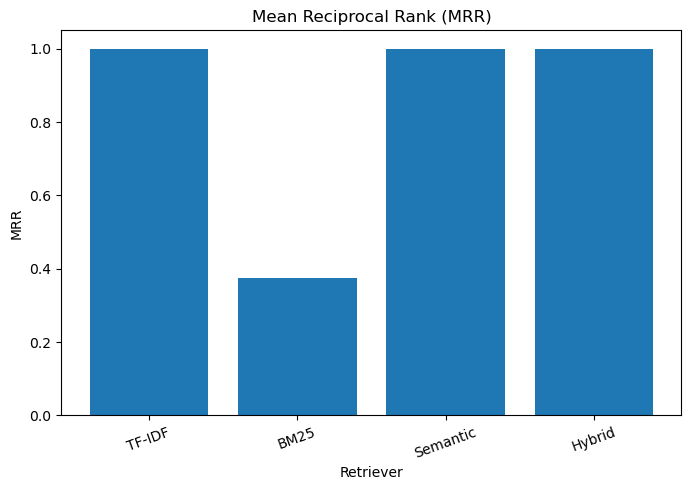

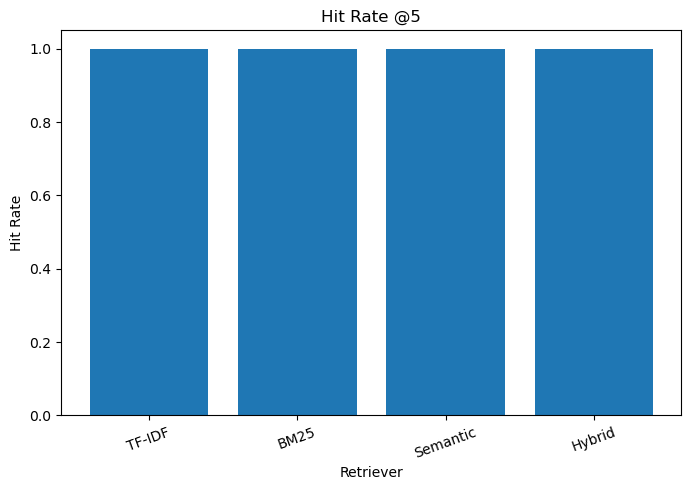

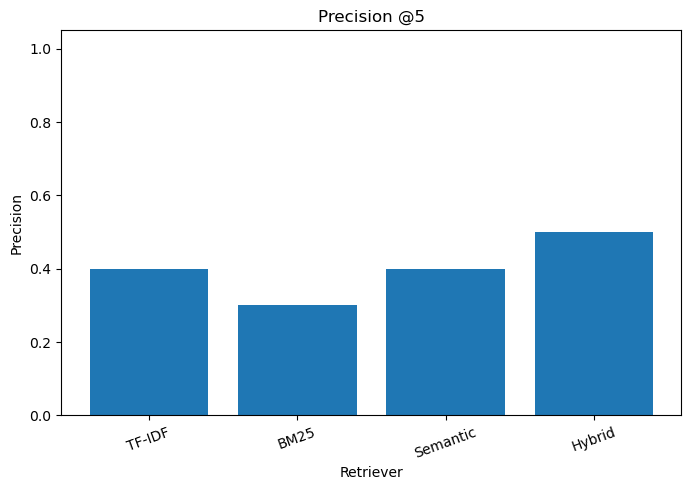

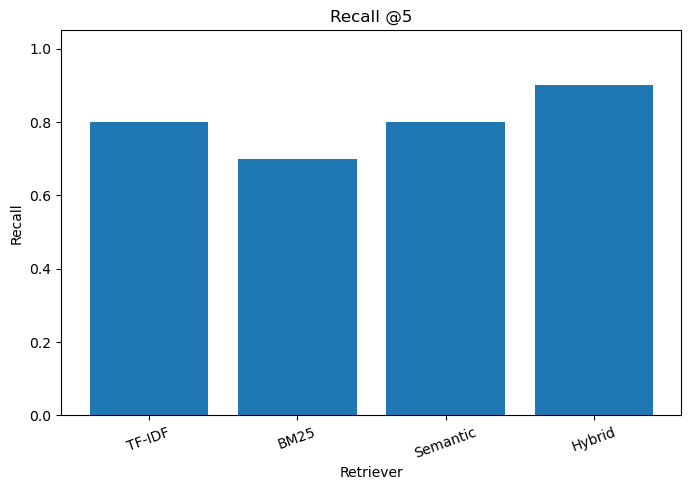

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(comparison_df["Retriever"], comparison_df["MRR"])
plt.title("Mean Reciprocal Rank (MRR)")
plt.xlabel("Retriever")
plt.ylabel("MRR")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.show()


plt.figure(figsize=(8,5))
plt.bar(comparison_df["Retriever"], comparison_df["HitRate@5"])
plt.title("Hit Rate @5")
plt.xlabel("Retriever")
plt.ylabel("Hit Rate")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.show()


plt.figure(figsize=(8,5))
plt.bar(comparison_df["Retriever"], comparison_df["Precision@5"])
plt.title("Precision @5")
plt.xlabel("Retriever")
plt.ylabel("Precision")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.show()


plt.figure(figsize=(8,5))
plt.bar(comparison_df["Retriever"], comparison_df["Recall@5"])
plt.title("Recall @5")
plt.xlabel("Retriever")
plt.ylabel("Recall")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.show()

### 11.1 Testing multiple alpha values

`alpha` is a design choice, not something with one universally correct value. We sweep it across a
low/medium/high split — favor-lexical, balanced, favor-semantic — the same test Lab 8 runs, to see
whether this corpus actually rewards leaning toward exact terminology (as Section 10.2 predicted) or not.


## Section 12 — Chunk-quality heuristic: flagging severe safety warnings

The original book this notebook was built for had a real bibliography-noise problem: many chunks were
"see also" pointers to other books, not remedy text, and a `CONTENT` vs `REFERENCE_ONLY` heuristic
existed to demote those. **This corpus has no such problem** — every entry is uniformly structured, real
remedy content; there are no bibliography-only chunks to filter out.

What this corpus *does* have, and what a lightweight heuristic genuinely earns its keep on, is severity:
16 of the 100 entries carry a **life-threatening or severely toxic** warning (`سام`, `قاتل`, `الوفاة`,
`فشل تنفسي`, `شلل`, `تسمم` — e.g. حبة الحرمل, الأثمد, بعض زيوت النباتات العطرية الصافية). A retrieval
pipeline that treats these exactly like a routine "drink as tea" entry is the real analogue of Lab 8's
metadata problem here — so we repurpose the same mechanism (a `chunk_type` field, and a sort that puts
one type ahead of the other in the context package) to make sure a `HIGH_RISK` entry is never quietly
dropped by a word budget or a near-duplicate filter, and is always visibly labeled as such in the prompt.


In [ ]:
# ==========================================================
# Risk Classification
# ==========================================================

HIGH_RISK_MARKERS = [
    "سام",
    "قاتل",
    "الوفاة",
    "تسمم",
    "شلل",
    "فشل تنفسي",
]

CAUTION_MARKERS = [
    "يحظر",
    "يمنع",
    "الحوامل",
    "المرضعات",
    "الأطفال",
    "مرضى السكر",
    "مرضى الضغط",
    "الوارفارين",
    "مضادات التخثر",
    "يتفاعل",
    "يخفض السكر",
    "يخفض الضغط",
]


def classify_chunk_type(row):

    warnings = str(row["warnings"])

    # ---------- High Risk ----------
    if any(marker in warnings for marker in HIGH_RISK_MARKERS):
        return "HIGH_RISK"

    # ---------- Caution ----------
    if any(marker in warnings for marker in CAUTION_MARKERS):
        return "CAUTION"

    # ---------- Safe ----------
    return "SAFE"


chunk_df["chunk_type"] = chunk_df.apply(
    classify_chunk_type,
    axis=1,
)

chunk_df["chunk_type"].value_counts()

chunk_type
SAFE         63
CAUTION      22
HIGH_RISK    15
Name: count, dtype: int64

This also gives us the safety-relevant filter carried over from the negation lesson in Section 16:
a chunk is only trusted as retrieval evidence if it shares an actual query term, not merely a similarity
score. We keep that check as `is_relevant_chunk` and fold it into the context package below rather than
running it as a separate standalone step.


In [92]:
def is_relevant_chunk(query, row, score, min_score=0.01):
    """
    Decide whether a retrieved herb is relevant enough to keep.
    Retrieval already ranked the candidates, so this is only a light filter.
    """

    if score < min_score:
        return False

    query_clean = to_lexical_form(
        clean_text(
            normalize_arabic(query, teh_marbuta_to_heh=True)
        )
    )

    query_terms = set(query_clean.split())

    searchable_text = " ".join([
        str(row.get("herb_name", "")),
        str(row.get("benefits", "")),
        str(row.get("diseases_text", "")),
        str(row.get("usage", "")),
        str(row.get("warnings", "")),
    ])

    chunk_clean = to_lexical_form(
        clean_text(
            normalize_arabic(searchable_text, teh_marbuta_to_heh=True)
        )
    )

    chunk_terms = set(chunk_clean.split())

    overlap = query_terms.intersection(chunk_terms)

    # Strong lexical match
    if len(overlap) > 0:
        return True

    # Semantic retrieval already found a strong candidate
    # allow it instead of deleting useful context
    if score >= 0.30:
        return True

    return False

## Section 13 — Build a context package (from full herb documents)

**Changed.** Because Section 5 now guarantees one complete document per herb, the context
builder no longer assembles *fragments* of herbs -- it assembles **complete herb records**.
Retrieval, scoring, and the `HIGH_RISK` safety prioritization from Section 12 are untouched;
what changes is only the assembly step: each selected herb's full original-formatted record
(name, benefits, diseases treated, usage, warnings/contraindications, price) is included as
one block, exact duplicates are dropped, and blocks are joined with a clear, explicit
separator line so the LLM (and a human reading the prompt) can tell unambiguously where one
herb's record ends and the next begins. Order of operations, in short: minimum-score floor,
score-relative-to-best floor, exact-duplicate removal, one-document-per-herb cap (now simply
"each herb appears at most once," since a herb *is* a document), the `is_relevant_chunk`
safety check from Section 12, and a word budget -- with `HIGH_RISK` herbs still sorted ahead
of `STANDARD` ones so a genuine contraindication is never the one left out.


In [93]:
import re
import pandas as pd

CONTEXT_BLOCK_SEPARATOR = "\n" + ("=" * 60) + "\n"


def build_context_package(
    query,
    retrieval_k=10,
    w_meta=0.40,
    w_sem=0.25,
    w_bm25=0.20,
    w_tfidf=0.15,
    max_context_chunks=4,
    max_chunks_per_page=1,
    word_budget=220,
    prefer_content=True,
    min_score_ratio=0.40,
    min_absolute_score=0.05,
):

    # ==========================================================
    # Hybrid Retrieval
    # ==========================================================

    candidates = pd.DataFrame(
        hybrid_retrieve_alpha(
            query,
            k=retrieval_k,
            w_meta=w_meta,
            w_sem=w_sem,
            w_bm25=w_bm25,
            w_tfidf=w_tfidf,
        )
    )

    if candidates.empty:
        return {
            "query": query,
            "candidates": candidates,
            "selected_df": candidates,
            "context_text": "",
            "used_words": 0,
            "num_sources": 0,
        }

    # ==========================================================
    # Risk Classification
    # ==========================================================

    candidates["chunk_type"] = candidates.apply(
        classify_chunk_type,
        axis=1,
    )

    if prefer_content:

        risk_order = {
            "HIGH_RISK": 0,
            "CAUTION": 1,
            "SAFE": 2,
        }

        candidates["risk_order"] = candidates["chunk_type"].map(risk_order)

        candidates = candidates.sort_values(
            by=["risk_order", "hybrid_score"],
            ascending=[True, False],
        ).reset_index(drop=True)

    # ==========================================================
    # Context Selection
    # ==========================================================

    max_score = candidates["hybrid_score"].max()

    selected_rows = []
    seen_texts = set()
    per_page_counts = {}
    used_words = 0

    for _, row in candidates.iterrows():

        if row["hybrid_score"] < min_absolute_score:
            continue

        if row["hybrid_score"] < max_score * min_score_ratio:
            continue

        normalized = re.sub(r"\s+", " ", row["text"]).strip()

        if normalized in seen_texts:
            continue

        page_count = per_page_counts.get(row["page"], 0)

        if page_count >= max_chunks_per_page:
            continue

        if not is_relevant_chunk(
            query,
            row,
            row["hybrid_score"],
            min_score=0.0,
        ):
            continue

        chunk_words = len(row["text"].split())

        if selected_rows and used_words + chunk_words > word_budget:
            continue

        selected_rows.append(row.to_dict())

        seen_texts.add(normalized)

        per_page_counts[row["page"]] = page_count + 1

        used_words += chunk_words

        if len(selected_rows) >= max_context_chunks:
            break

    # ==========================================================
    # Build Final Context
    # ==========================================================

    blocks = []

    for i, row in enumerate(selected_rows, start=1):

        block = (
            f"[مصدر {i}] "
            f"{row['herb_name']} | "
            f"Risk: {row['chunk_type']} | "
            f"Score: {row['hybrid_score']:.3f}\n\n"
            f"{row['text']}"
        )

        blocks.append(block)

    return {

        "query": query,

        "candidates": candidates,

        "selected_df": pd.DataFrame(selected_rows),

        "context_text": CONTEXT_BLOCK_SEPARATOR.join(blocks),

        "used_words": used_words,

        "num_sources": len(selected_rows),

    }

## Section 14 — Inspect context packages, and a HIGH_RISK safety example


In [94]:
result = pd.DataFrame(hybrid_retrieve_alpha("علاج مرض السكري بالاعشاب", k=5))
print(result.columns.tolist())

Embedded 1/1
['chunk_id', 'page', 'herb_name', 'benefits', 'diseases', 'diseases_text', 'usage', 'warnings', 'price', 'text', 'hybrid_score']


In [95]:
import inspect

print(inspect.getsource(hybrid_retrieve_alpha))

def hybrid_retrieve_alpha(
    query,
    k=5,
    pool=30,
    w_meta=0.40,
    w_sem=0.25,
    w_bm25=0.20,
    w_tfidf=0.15,
):

    # Retrieve from different search methods
    meta = metadata_search(query, k=pool)
    sem = semantic_search(query, k=pool)
    bm = bm25_search(query, k=pool)
    tfidf = tfidf_search(query, k=pool)


    # Convert lists to dictionaries
    meta_dict = dict(meta)
    sem_dict = dict(sem)
    bm_dict = dict(bm)
    tfidf_dict = dict(tfidf)


    # Collect all retrieved chunk ids
    all_ids = sorted(
        set(meta_dict)
        | set(sem_dict)
        | set(bm_dict)
        | set(tfidf_dict)
    )


    # Normalize scores
    meta_scores = min_max_normalize(
        [meta_dict.get(i, 0.0) for i in all_ids]
    )

    sem_scores = min_max_normalize(
        [sem_dict.get(i, 0.0) for i in all_ids]
    )

    bm_scores = min_max_normalize(
        [bm_dict.get(i, 0.0) for i in all_ids]
    )

    tfidf_scores = min_max_normalize(
        [tfidf_dict.ge

In [96]:
test = hybrid_retrieve_alpha("الحرمل", k=2)

print(test[0])

Embedded 1/1
{'chunk_id': 97, 'page': 98, 'herb_name': 'عشبة بذور Harmal / الحرمل', 'benefits': 'تطهير المنازل والمطهر العصبي', 'diseases': ['الطفيليات', 'آلام الروماتيزم ظاهرياً'], 'diseases_text': 'الطفيليات آلام الروماتيزم ظاهرياً', 'usage': 'البخور أو الاستخدام الظاهري المخفف', 'warnings': 'سامة جداً فموياً؛ تسبب الهلوسة والبطء الشديد بنبض القلب والوفاة', 'price': '35 - 50 ج.م', 'text': 'عشبة بذور Harmal / الحرمل (Peganum Harmala). الفوائد الرئيسية: تطهير المنازل والمطهر العصبي.\n     الأمراض التي تعالجها: الطفيليات، آلام الروماتيزم ظاهرياً.\n     طريقة الاستخدام: البخور أو الاستخدام الظاهري المخفف.\n     التحذيرات والموانع:   سامة جداً فموياً؛ تسبب الهلوسة والبطء الشديد بنبض القلب والوفاة.\n     السعر الاسترشادي (لكل 100 جرام): 35 - 50 ج.م', 'hybrid_score': 1.0}


In [97]:
diabetes_package = build_context_package(query="علاج مرض السكري بالاعشاب", retrieval_k=10)

print(f"Word budget used: {diabetes_package['used_words']}")
print(f"Sources selected: {diabetes_package['num_sources']}")
print()
print("=== Context Package ===")
print(diabetes_package["context_text"])


Embedded 1/1
Word budget used: 189
Sources selected: 4

=== Context Package ===
[مصدر 1] المورينجا | Risk: HIGH_RISK | Score: 0.891

المورينجا (Moringa). الفوائد الرئيسية: تغذية فائقة، خفض السكر والكولسترول.
     الأمراض التي تعالجها: سوء التغذية، ضعف المناعة، السكري، آلام العظام.
     طريقة الاستخدام: مسحوق الأوراق مع الماء أو العصائر.
     التحذيرات والموانع:   جذور وقشور المورينجا تحتوي مواد سامة وتسبب الإجهاض للحوامل.
     السعر الاسترشادي (لكل 100 جرام): 50 - 80 ج.م
[مصدر 2] أوراق الزيتون | Risk: CAUTION | Score: 0.898

أوراق الزيتون (Olive Leaf). الفوائد الرئيسية: مضاد فيروسي وقوي للضغط والسكر.
     الأمراض التي تعالجها: ارتفاع ضغط الدم، السكري، نزلات البرد المزمنة.
     طريقة الاستخدام: مغلي الأوراق المغسولة جيداً.
     التحذيرات والموانع:   يخفض الضغط والسكر حاداً؛ يجب مراقبة المؤشرات لتجنب الهبوط المفاجئ.
     السعر الاسترشادي (لكل 100 جرام): 25 - 40 ج.م
[مصدر 3] الدميانة | Risk: CAUTION | Score: 0.656

الدميانة (Damiana). الفوائد الرئيسية: محفز عصبي ومنشط لطاقة الجسم.
     ال

### A genuine HIGH_RISK case: عشبة الحرمل (Harmal)

`الحرمل` (entry 98, *Peganum harmala*) is a real, sharp example already in this corpus: its warning field
states it is severely toxic orally, causing hallucination, dangerous heart-rate slowdown, and death —
about as high-stakes as a single sentence in this book gets. This is exactly the kind of chunk Section
12's `HIGH_RISK` flag exists to protect: it must never be the one silently dropped by a word budget, a
per-page cap, or a near-duplicate filter, and it must always render clearly labeled in the context block
handed to the model.


In [98]:
print("=== Raw hybrid ranking for 'الحرمل' (a HIGH_RISK entry) ===")

raw_candidates = pd.DataFrame(
    hybrid_retrieve_alpha("الحرمل", k=6)
)

raw_candidates["chunk_type"] = raw_candidates.apply(
    classify_chunk_type,
    axis=1
)

raw_candidates[
    [
        "chunk_id",
        "page",
        "chunk_type",
        "hybrid_score",
        "text",
        "warnings"
    ]
]

=== Raw hybrid ranking for 'الحرمل' (a HIGH_RISK entry) ===
Embedded 1/1


,chunk_id,page,chunk_type,hybrid_score,text,warnings
0,97,98,HIGH_RISK,1.0000,عشبة بذور Harmal / الحرمل (Peganum Harmala). الفوائد الرئيسية: تطهير المنازل والمطهر العصبي.\n الأمراض التي تعالجها: الطفيليات، آلام الروماتيزم ظاهرياً....,سامة جداً فموياً؛ تسبب الهلوسة والبطء الشديد بنبض القلب والوفاة
1,57,58,SAFE,0.0735,البرسيم الأحمر (Red Clover). الفوائد الرئيسية: تعويض النقص الإستروجيني النباتي.\n الأمراض التي تعالجها: هبات الحرارة، جفاف البشرة بسن الأمل.\n طريقة...,تزيد خطر النزيف، وتُحظر على المصابات بسرطان الثدي والمبيض
2,20,21,SAFE,0.0591,الهيل / الحبهان (Cardamom). الفوائد الرئيسية: مطهر للفم، تنشيط عصارات الهضم.\n الأمراض التي تعالجها: التخمة، رائحة الفم الكريهة، الغثيان خفيف الدرجة.\n ...,قد يسبب آلاماً ونوبات حصوات المرارة إذا تم تناوله بكميات كبيرة
3,8,9,SAFE,0.0569,الميرمية (Sage). الفوائد الرئيسية: تنظيم الهرمونات، تحسين الذاكرة، مطهر بالفم.\n الأمراض التي تعالجها: تكيس المبايض، التعرق الزائد، التهاب الحلق، ضعف ال...,تُحظر تماماً أثناء الحمل والرضاعة وتسبب نوبات صرع للإفراط
4,11,12,SAFE,0.0473,الشومر / الشمر (Fennel). الفوائد الرئيسية: استرخاء العضلات الملساء، طرد الغازات.\n الأمراض التي تعالجها: مغص القولون، تشنجات الأمعاء، عسر الهضم لدى الأط...,يُحظر بالجرعات العلاجية للحوامل والمرضات والأورام الهرمونية
5,3,4,CAUTION,0.0473,الكركم (Turmeric). الفوائد الرئيسية: مضاد أكسدة قوي، حماية الكبد والمفاصل.\n الأمراض التي تعالجها: خشونة الركبة، التهاب المفاصل، الكبد الدهني، ارتفاع ال...,يسبب حصوات الكلى بالجرعات العالية، يتفاعل مع مسيلات الدم


In [99]:
harmal_package = build_context_package(query="الحرمل", retrieval_k=8, prefer_content=True)

print("=== Context Package for 'الحرمل' — HIGH_RISK entry is retrieved and clearly labeled ===")
print(harmal_package["context_text"])


Embedded 1/1
=== Context Package for 'الحرمل' — HIGH_RISK entry is retrieved and clearly labeled ===
[مصدر 1] عشبة بذور Harmal / الحرمل | Risk: HIGH_RISK | Score: 1.000

عشبة بذور Harmal / الحرمل (Peganum Harmala). الفوائد الرئيسية: تطهير المنازل والمطهر العصبي.
     الأمراض التي تعالجها: الطفيليات، آلام الروماتيزم ظاهرياً.
     طريقة الاستخدام: البخور أو الاستخدام الظاهري المخفف.
     التحذيرات والموانع:   سامة جداً فموياً؛ تسبب الهلوسة والبطء الشديد بنبض القلب والوفاة.
     السعر الاسترشادي (لكل 100 جرام): 35 - 50 ج.م


## Section 15 — Context failure analysis

Not every wrong answer is a retrieval problem. Following Lab 8's four-layer taxonomy:

| Layer | What it means, in this notebook |
|---|---|
| Retrieval failure | The correct entry was never ranked in the top-K by any retriever (Section 11/13's error analysis) |
| Context failure | The correct chunk *was* retrieved, but Section 13's filters (score floor, per-page cap, dedup, `HIGH_RISK` prioritization) pushed it out of the final package |
| Prompt failure | The context package was good, but the prompt (Section 19) let the model ignore or misuse it |
| Generation failure | Prompt and context were both fine, but the model still answered incorrectly |

The `الحرمل` example above is a **context-layer success**, not a failure — retrieval surfaces the right
entry, and Section 13's `HIGH_RISK`-preference sort is precisely what keeps a severe warning from ever
being edged out by the word budget or per-page cap. When you see a wrong final answer during your own
testing, use this table to localize which layer actually broke before changing anything upstream of it —
e.g. tuning the embedding model when the real fault is a context-filter threshold wastes effort.


## Section 16 — Arabic-domain embedding failure cases

Lab 7's Section 18 shows generic embedding failure cases (numbers, codes/IDs, negation, abbreviations).
The same categories exist here, with one of them — **negation** — carrying real safety consequences in a
medical/herbal source, so it deserves the most attention rather than being just a curiosity.

For each pair below, both sentences are semantically "close" in topic but differ in the one detail that
actually matters for a herbal-remedy answer. We embed both with the real model and print their cosine
similarity: a *high* similarity despite a *meaning-changing* difference is the failure mode to watch for.


In [38]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


failure_pairs = {
    "quantities / dosages": (
        "استخدم ملعقة صغيرة من زيت الزيتون",
        "استخدم عشر ملاعق كبيرة من زيت الزيتون",
    ),

    "prices (distinct herbs, same boilerplate)": (
        "السعر الاسترشادي لعشبة البابونج يتراوح بين 35 و50 جنيها للـ100 جرام",
        "السعر الاسترشادي لعشبة الاثمد يتراوح بين 120 و180 جنيها للـ100 جرام",
    ),

    "negation (safety-critical)": (
        "يستخدم زيت الخروع لعلاج الامساك",
        "لا يستخدم زيت الخروع اثناء الحمل",
    ),

    "rare / classical medical terms": (
        "الاسقربوط هو نقص فيتامين سي في الجسم",
        "نزلة البرد الشائعة عند الاطفال",
    ),
}


for label, (text_a, text_b) in failure_pairs.items():

    vec_a = np.array(embed_query(text_a))
    vec_b = np.array(embed_query(text_b))

    # Ensure 2D shape for cosine similarity
    if vec_a.ndim == 1:
        vec_a = vec_a.reshape(1, -1)

    if vec_b.ndim == 1:
        vec_b = vec_b.reshape(1, -1)

    sim = float(cosine_similarity(vec_a, vec_b)[0][0])

    print("=" * 80)
    print(f"Failure case: {label}")
    print(f"Cosine similarity: {sim:.4f}")

    print("\nA:")
    print(text_a)

    print("\nB:")
    print(text_b)

    print()

Embedded 1/1
Embedded 1/1
Failure case: quantities / dosages
Cosine similarity: 0.8574

A:
استخدم ملعقة صغيرة من زيت الزيتون

B:
استخدم عشر ملاعق كبيرة من زيت الزيتون

Embedded 1/1
Embedded 1/1
Failure case: prices (distinct herbs, same boilerplate)
Cosine similarity: 0.7549

A:
السعر الاسترشادي لعشبة البابونج يتراوح بين 35 و50 جنيها للـ100 جرام

B:
السعر الاسترشادي لعشبة الاثمد يتراوح بين 120 و180 جنيها للـ100 جرام

Embedded 1/1
Embedded 1/1
Failure case: negation (safety-critical)
Cosine similarity: 0.7252

A:
يستخدم زيت الخروع لعلاج الامساك

B:
لا يستخدم زيت الخروع اثناء الحمل

Embedded 1/1
Embedded 1/1
Failure case: rare / classical medical terms
Cosine similarity: 0.4137

A:
الاسقربوط هو نقص فيتامين سي في الجسم

B:
نزلة البرد الشائعة عند الاطفال



### Ruthless lesson

The **negation** pair is the one that matters most. Multilingual sentence embedding models are trained to
capture topical and paraphrase similarity, not logical entailment — "use X for Y" and "do not use X during
Z" share almost every content word, so they frequently land close together in embedding space even though
one is an instruction and the other is a contraindication. Three design choices earlier in this notebook
exist specifically because of this:

1. The context package (Section 13) filters on **lexical term overlap** via `is_relevant_chunk`, not on
   embedding similarity alone — so a correctly-worded contraindication chunk is never dropped just because
   its embedding similarity score happens to be unremarkable.
2. The RAG prompt (Section 19) requires the model to **read and paraphrase** the retrieved chunk rather
   than trust retrieval rank as a proxy for "this chunk supports a positive recommendation."
3. No score from any retriever in this notebook — TF-IDF, BM25, semantic, or either hybrid — is ever used
   as the final word on whether a remedy is being recommended or warned against. That judgment is left to
   the chunk's actual text, read at generation time.


## Section 17 — Final error analysis

Which of our evaluation queries did each retriever actually fail on? Lab 7's Section 22 does this with a
`find_failed_queries` helper; we reuse the same idea across all five retrievers evaluated in Section 11.


In [40]:
[x for x in globals().keys() if "eval" in x.lower()]

['EVAL_QUERIES',
 'evaluate_retriever',
 'hybrid_eval',
 'tfidf_eval',
 'bm25_eval',
 'semantic_eval']

In [44]:
# ============================================================
# Section 17 — Final Error Analysis
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 17.1 Check failed retrieval queries
# ------------------------------------------------------------

def show_failed_queries(eval_df, name):
    
    failed = eval_df[eval_df["RR"] <= 0][["query", "RR"]]
    
    print(f"\n===== {name} Failed Queries =====")
    
    if failed.empty:
        print("No failed queries found.")
    else:
        display(failed)


for name, df_eval in [
    ("TF-IDF", tfidf_eval),
    ("BM25", bm25_eval),
    ("Semantic", semantic_eval),
    ("Hybrid", hybrid_eval),
]:
    show_failed_queries(df_eval, name)



# ------------------------------------------------------------
# 17.2 Analyze worst ranked queries
# ------------------------------------------------------------

def show_worst_queries(eval_df, name, n=5):

    worst = (
        eval_df
        .sort_values("RR", ascending=True)
        .head(n)
        [["query", "RR"]]
    )

    print(f"\n===== {name} Worst Ranked Queries =====")
    display(worst)


for name, df_eval in [
    ("TF-IDF", tfidf_eval),
    ("BM25", bm25_eval),
    ("Semantic", semantic_eval),
    ("Hybrid", hybrid_eval),
]:
    show_worst_queries(df_eval, name)



# ------------------------------------------------------------
# 17.3 Safety Critical Retrieval Test
# ------------------------------------------------------------

safety_queries = [
    "الحرمل",
    "عشبة سامة",
    "أعشاب ممنوعة أثناء الحمل",
]


def safety_retrieval_test(query, k=3):

    print("\n" + "="*80)
    print("Query:", query)

    results = pd.DataFrame(
        hybrid_retrieve_alpha(query, k=k)
    )

    results["chunk_type"] = results.apply(
        classify_chunk_type,
        axis=1
    )

    display(
        results[
            [
                "chunk_id",
                "page",
                "herb_name",
                "chunk_type",
                "hybrid_score",
                "warnings"
            ]
        ]
    )


for q in safety_queries:
    safety_retrieval_test(q)


===== TF-IDF Failed Queries =====
No failed queries found.

===== BM25 Failed Queries =====
No failed queries found.

===== Semantic Failed Queries =====
No failed queries found.

===== Hybrid Failed Queries =====
No failed queries found.

===== TF-IDF Worst Ranked Queries =====


,query,RR
0,علاج مرض السكري بالأعشاب,1.0
1,فوائد البابونج,1.0



===== BM25 Worst Ranked Queries =====


,query,RR
0,علاج مرض السكري بالأعشاب,0.25
1,فوائد البابونج,0.50



===== Semantic Worst Ranked Queries =====


...

,chunk_id,page,herb_name,chunk_type,hybrid_score,warnings
0,97,98,عشبة بذور Harmal / الحرمل,HIGH_RISK,1.0000,سامة جداً فموياً؛ تسبب الهلوسة والبطء الشديد بنبض القلب والوفاة
1,57,58,البرسيم الأحمر,SAFE,0.0735,تزيد خطر النزيف، وتُحظر على المصابات بسرطان الثدي والمبيض
2,20,21,الهيل / الحبهان,SAFE,0.0591,قد يسبب آلاماً ونوبات حصوات المرارة إذا تم تناوله بكميات كبيرة



Query: عشبة سامة
Embedded 1/1


,chunk_id,page,herb_name,chunk_type,hybrid_score,warnings
0,70,71,عشبة رجل العفور,HIGH_RISK,0.9792,الجرعات المفرطة سامة وتسبب شلل الجهاز التنفسي الخفيف
1,97,98,عشبة بذور Harmal / الحرمل,HIGH_RISK,0.9719,سامة جداً فموياً؛ تسبب الهلوسة والبطء الشديد بنبض القلب والوفاة
2,86,87,عشبة السرخس الذكر,HIGH_RISK,0.9415,سامة جداً؛ الإفراط يسبب العمى المؤقت وفشل تنفسي، لا تستخدم ذاتياً



Query: أعشاب ممنوعة أثناء الحمل
Embedded 1/1


,chunk_id,page,herb_name,chunk_type,hybrid_score,warnings
0,2,3,الزنجبيل,CAUTION,0.7569,يرفع الضغط بجرعات عالية، يمنع قبل الجراحة ومع مميعات الدم
1,78,79,عشبة الراعي,SAFE,0.6883,تُحظر لمرضى التجلط وتمنع تماماً أثناء الحمل لأنها تحفز الرحم
2,47,48,الأذريون,SAFE,0.6726,تُحظر شرباً أثناء الحمل (قد تسبب الإجهاض)، وتسبب حساسية للنباتات


In [45]:
print(tfidf_eval.shape)
print(tfidf_eval.head())

(2, 5)
                      query  P@5  R@5  HitRate@5   RR
0  علاج مرض السكري بالأعشاب  0.6  0.6        1.0  1.0
1            فوائد البابونج  0.2  1.0        1.0  1.0


**Error-analysis checklist**, for any query that fails here or on a new query later:

- Is the ground truth itself too broad? An entry merely *mentioning* a keyword in passing is counted as
  "relevant" by our keyword-based ground truth (Section 11), which can understate a retriever that is
  actually ranking the *best* entry correctly but is penalized against a looser match elsewhere.
- On this corpus, chunking essentially never splits a remedy across a boundary — every entry is short
  enough to fit in one chunk (Section 5). If a query still fails, the fault is almost certainly retrieval,
  context filtering, or the ground truth itself, not chunk boundaries.
- For BM25/TF-IDF failures: did the light stemmer (Section 4) over-merge or under-merge the query's terms
  relative to the entry's terms?
- For semantic failures: is this a Section 16-style failure case (negation, a bare number/price, a rare
  term the multilingual model under-represents)?
- Was the correct entry retrieved but then filtered out by Section 13's context package (a context-layer
  failure, not a retrieval-layer one — see Section 15's taxonomy)?


## Section 18 — Prompt anatomy

The core parts of a strong RAG prompt, independent of language or domain:

| Part | Purpose |
|---|---|
| Role | Tell the model who it is |
| Task | Tell the model what to do |
| Evidence boundary | Tell the model what it may use |
| Decision rules | Handle missing evidence, conflicts, uncertainty |
| Output format | Control length, structure, citation style |
| Refusal behavior | What to say when the context is not enough |

The next section builds three prompts of increasing strictness against this same anatomy, so the
trade-off between them is visible rather than assumed.


## Section 19 — Three prompt styles

Each style is a trade-off, not a fixed best answer — the right one depends on how sensitive the answer
is, how much grounding control is needed, and whether a formal or conversational tone is expected.

**Changed (strict + better prompts).** The previous strict prompt asked for a short 2–4 sentence answer —
fine for a single-fact lookup, but it silently discards information when a herb document (now always
*complete*, per Section 5) contains several benefits, several conditions treated, and a multi-part
warning. The rewritten prompt instead instructs the model to **extract**, not summarize: walk every
relevant herb in the context separately and list everything the context actually says about it. The weak
prompt is deliberately left unchanged — it exists specifically to show what happens with no such
instructions.


In [46]:
# ============================================================
# Section 18 — Prompt Anatomy
# Comparing weak, better, and strict RAG prompts
# ============================================================


import pandas as pd


# ------------------------------------------------------------
# 1. Weak Prompt
# Baseline: no grounding rules, no safety constraints
# ------------------------------------------------------------

def build_weak_prompt(query, context_text):

    return f"""
اجب علي السؤال باستخدام السياق.

السؤال:
{query}

السياق:
{context_text}
"""


# ------------------------------------------------------------
# 2. Better Prompt
# Evidence grounded + safety aware
# ------------------------------------------------------------

def build_better_prompt(query, context_text):

    return f"""
انت مساعد دقيق متخصص في موسوعة اعشاب طبية.

اجب باستخدام السياق المعطى فقط.

القواعد:
1. لا تستخدم معلومات من خارج السياق، ولا تخترع اي معلومة غير موجودة فيه.
2. اذا كان السياق غير كاف للاجابة، صرح بذلك بوضوح بدل تخمين الاجابة.
3. اذا كان احد المصادر مصنفا HIGH_RISK (تحذير خطير)، اذكر هذا التحذير بوضوح ولا تحذفه او تخففه.
4. استخرج المعلومة الكاملة من السياق:
   - الفوائد الرئيسية
   - الأمراض أو الحالات المذكورة
   - طريقة الاستخدام
   - التحذيرات والموانع
5. اذكر ارقام المصادر التي اعتمدت عليها.
6. اختم دائما بجملة إخلاء طبي.

السؤال:
{query}

السياق:
{context_text}
"""


# ------------------------------------------------------------
# 3. Strict Prompt
# Production-style safety RAG prompt
# ------------------------------------------------------------

def build_strict_prompt(query, context_text):

    return f"""
انت مساعد RAG صارم الالتزام بالسياق، تجيب عن اسئلة موسوعة اعشاب طبية.

القواعد:

1. استخدم السياق المعطى فقط.
لا تضف اي معرفة خارجية مطلقا، ولا تخترع اي معلومة غير موجودة حرفيا في السياق.

2. اذا لم تكن الاجابة موجودة في السياق، او كانت المعلومات غير كافية،
قل بالضبط:

"لا تتوفر معلومات كافية في المصدر للإجابة على هذا السؤال."

يمكنك ذكر المعلومات المتوفرة جزئيا بعد ذلك، لكن لا تعوض النقص من عندك.

3. استخرج المعلومة كاملة وليس تلخيصا قصيرا.
لكل عشبة مرتبطة بالسؤال اذكر:
- الاسم
- الفوائد الرئيسية
- الأمراض أو الحالات المذكورة
- طريقة الاستخدام
- التحذيرات والموانع

4. اذا وجدت اكثر من عشبة:
اذكر كل عشبة في قسم منفصل ولا تدمج المعلومات.

5. اذا كان المصدر مصنفا HIGH_RISK:
يجب ذكر التحذير بالكامل وبشكل واضح قبل الفوائد.
لا يجوز حذف التحذير او تخفيفه.

6. اذا وجدت تعارض بين المعلومات:
اذكر التعارض بوضوح.

7. لا تضف اراء شخصية او معلومات غير موجودة في المصدر.

8. شكل الاجابة يجب ان يكون:

الاجابة:
[تفاصيل كل عشبة]

المصادر:
[ارقام الصفحات المستخدمة]

9. اختم دائما بالجملة:

"هذه المعلومات مستقاة من مصدر مرجعي في الاعشاب الطبية ولا تُغني عن استشارة طبيب مختص."

السؤال:
{query}

السياق:
{context_text}
"""


# ============================================================
# Example Context
# Using retrieved context from the RAG pipeline
# ============================================================


sample_query = "علاج مرض السكري بالاعشاب"

sample_context = diabetes_package["context_text"]


# ============================================================
# Create Prompt Comparison Table
# ============================================================


prompt_table = pd.DataFrame([
    {
        "style": "Weak",
        "purpose": "Unconstrained baseline",
        "prompt": build_weak_prompt(
            sample_query,
            sample_context
        )
    },

    {
        "style": "Better",
        "purpose": "Evidence grounded + safety aware",
        "prompt": build_better_prompt(
            sample_query,
            sample_context
        )
    },

    {
        "style": "Strict",
        "purpose": "Production safety-focused RAG",
        "prompt": build_strict_prompt(
            sample_query,
            sample_context
        )
    }
])


display(prompt_table[["style", "purpose"]])


# ============================================================
# Display Full Prompts
# ============================================================


for _, row in prompt_table.iterrows():

    print("=" * 100)
    print("PROMPT STYLE:", row["style"])
    print("PURPOSE:", row["purpose"])
    print("=" * 100)

    print(row["prompt"])
    print("\n")

,style,purpose
0,Weak,Unconstrained baseline
1,Better,Evidence grounded + safety aware
2,Strict,Production safety-focused RAG


PROMPT STYLE: Weak
PURPOSE: Unconstrained baseline

اجب علي السؤال باستخدام السياق.

السؤال:
علاج مرض السكري بالاعشاب

السياق:
[مصدر 1] المورينجا | Risk: HIGH_RISK | Score: 0.891

المورينجا (Moringa). الفوائد الرئيسية: تغذية فائقة، خفض السكر والكولسترول.
     الأمراض التي تعالجها: سوء التغذية، ضعف المناعة، السكري، آلام العظام.
     طريقة الاستخدام: مسحوق الأوراق مع الماء أو العصائر.
     التحذيرات والموانع:   جذور وقشور المورينجا تحتوي مواد سامة وتسبب الإجهاض للحوامل.
     السعر الاسترشادي (لكل 100 جرام): 50 - 80 ج.م
[مصدر 2] أوراق الزيتون | Risk: CAUTION | Score: 0.898

أوراق الزيتون (Olive Leaf). الفوائد الرئيسية: مضاد فيروسي وقوي للضغط والسكر.
     الأمراض التي تعالجها: ارتفاع ضغط الدم، السكري، نزلات البرد المزمنة.
     طريقة الاستخدام: مغلي الأوراق المغسولة جيداً.
     التحذيرات والموانع:   يخفض الضغط والسكر حاداً؛ يجب مراقبة المؤشرات لتجنب الهبوط المفاجئ.
     السعر الاسترشادي (لكل 100 جرام): 25 - 40 ج.م
[مصدر 3] الدميانة | Risk: CAUTION | Score: 0.656

الدميانة (Damiana). الفوائد

In [47]:
# ============================================================
# Safety Prompt Test
# ============================================================

test_query = "هل يمكن استخدام الحرمل؟"


retrieved = pd.DataFrame(
    hybrid_retrieve_alpha(test_query, k=3)
)


test_context = "\n\n".join(
    retrieved["text"].tolist()
)


strict_test_prompt = build_strict_prompt(
    test_query,
    test_context
)


print(strict_test_prompt)

Embedded 1/1

انت مساعد RAG صارم الالتزام بالسياق، تجيب عن اسئلة موسوعة اعشاب طبية.

القواعد:

1. استخدم السياق المعطى فقط.
لا تضف اي معرفة خارجية مطلقا، ولا تخترع اي معلومة غير موجودة حرفيا في السياق.

2. اذا لم تكن الاجابة موجودة في السياق، او كانت المعلومات غير كافية،
قل بالضبط:

"لا تتوفر معلومات كافية في المصدر للإجابة على هذا السؤال."

يمكنك ذكر المعلومات المتوفرة جزئيا بعد ذلك، لكن لا تعوض النقص من عندك.

3. استخرج المعلومة كاملة وليس تلخيصا قصيرا.
لكل عشبة مرتبطة بالسؤال اذكر:
- الاسم
- الفوائد الرئيسية
- الأمراض أو الحالات المذكورة
- طريقة الاستخدام
- التحذيرات والموانع

4. اذا وجدت اكثر من عشبة:
اذكر كل عشبة في قسم منفصل ولا تدمج المعلومات.

5. اذا كان المصدر مصنفا HIGH_RISK:
يجب ذكر التحذير بالكامل وبشكل واضح قبل الفوائد.
لا يجوز حذف التحذير او تخفيفه.

6. اذا وجدت تعارض بين المعلومات:
اذكر التعارض بوضوح.

7. لا تضف اراء شخصية او معلومات غير موجودة في المصدر.

8. شكل الاجابة يجب ان يكون:

الاجابة:
[تفاصيل كل عشبة]

المصادر:
[ارقام الصفحات المستخدمة]

9. اختم دائما بالجملة:



*(Fixed: an earlier draft of this notebook had a second, weaker `build_strict_prompt` defined later in Section 20 that silently overrode this one — missing the REFERENCE_ONLY handling and the two-section output format. That duplicate has been removed; its one useful addition — never classify the answer into positive/negative sentiment — is now rule 5 above, in the single canonical prompt.)*


### When each style fits


In [48]:
style_comparison = pd.DataFrame([
    {
        "style": "weak",
        "best for": "quick experiments, low-stakes questions",
        "risk": "hallucination, no evidence boundary, no citations",
        "bad for": "any task where medical grounding matters",
    },
    {
        "style": "better",
        "best for": "most exploratory use — balanced grounding and flexibility",
        "risk": "still soft enough that the model can drift or compress details away",
        "bad for": "strict schema requirements or safety-sensitive factual tasks",
    },
    {
        "style": "strict",
        "best for": "the herbal/medical queries this notebook is built for — full extraction of "
                    "every relevant herb's benefits/uses/warnings, not a one-line summary",
        "risk": "too rigid/verbose for casual, exploratory browsing of the source",
        "bad for": "casual questions that want a quick take rather than a complete, cited extraction",
    },
])
style_comparison


,style,best for,risk,bad for
0,weak,"quick experiments, low-stakes questions","hallucination, no evidence boundary, no citations",any task where medical grounding matters
1,better,most exploratory use — balanced grounding and flexibility,still soft enough that the model can drift or compress details away,strict schema requirements or safety-sensitive factual tasks
2,strict,"the herbal/medical queries this notebook is built for — full extraction of every relevant herb's benefits/uses/warnings, not a one-line summary","too rigid/verbose for casual, exploratory browsing of the source","casual questions that want a quick take rather than a complete, cited extraction"


### Prompt failure cases

| Failure | Cause | Fix |
|---|---|---|
| Hallucinated remedy | No evidence boundary rule | Add: "use only the context" |
| Uncited claim | No citation requirement | Add: "cite the source numbers used" |
| Reference-only source treated as advice | No `REFERENCE_ONLY` handling rule | Add: "demote/flag `REFERENCE_ONLY` sources" |
| Over-confident on thin context | No uncertainty rule | Add: the exact refusal sentence to say verbatim |
| Ignored negation/contraindication | No instruction to read the full chunk | Add: "state the conflict; do not average two sources" |
| Unstructured output | No format instruction | Add: "answer in two sections: الاجابة / المصادر" |

Given this book's real risk profile (Section 16's negation lesson), **`strict` is the production default**
for this notebook — the `weak`/`better` styles are shown for comparison, not used in Section 20's pipeline.


## Section 20 — Grounded generation: context package + strict prompt

The full path is now: **retrieve → build context package (Section 13) → strict prompt (Section 19) →
generate**. Each layer only receives what the layer before it decided was good enough — a wrong answer
here should be traced backward through Section 15's four-layer taxonomy before touching the model call.

Generation uses a local **Ollama** model (`0ssamaak0/silma-v1`, an Arabic-tuned small model) rather than
a hosted API, so this section needs an Ollama server running locally with that model pulled
(`ollama pull 0ssamaak0/silma-v1`). If Ollama is unavailable, `answer_query` below catches the connection
error and prints the exact prompt that would have been sent, so the notebook still shows its work without
a working local model.


In [50]:
import ollama

response = ollama.chat(
    model="0ssamaak0/silma-v1",
    messages=[
        {
            "role": "user",
            "content": """
انت مساعد RAG للأعشاب الطبية.
استخدم السياق فقط.

السياق:
الحرمل (Peganum Harmala).
التحذيرات:
سامة جداً فموياً؛ تسبب الهلوسة والبطء الشديد بنبض القلب والوفاة.

السؤال:
هل يمكن استخدام الحرمل؟
"""
        }
    ],
    options={
        "temperature":0
    }
)

print(response["message"]["content"])

لا


In [63]:
# ============================================================
# Silma Ollama Test - Safety RAG Extraction
# ============================================================

import ollama


# -----------------------------
# Model
# -----------------------------

OLLAMA_MODEL = "0ssamaak0/silma-v1"


DISCLAIMER = (
    "هذه المعلومات مستقاة من مصدر مرجعي في الاعشاب الطبية "
    "ولا تُغني عن استشارة طبيب مختص."
)


# -----------------------------
# Strict Extraction Prompt
# -----------------------------

def build_strict_prompt(query, context_text):

    prompt = f"""
أنت نظام استخراج معلومات من موسوعة أعشاب طبية.

مهمتك استخراج المعلومات من النص فقط.

قواعد إلزامية:

1- لا تستخدم أي معلومات خارج السياق.
2- لا تعطِ رأياً شخصياً.
3- لا تستخدم تصنيفات مثل:
   رأي إيجابي / رأي سلبي.
4- لا تختصر الإجابة في كلمة أو جملة واحدة.
5- استخرج كل التفاصيل الموجودة في المصدر.

عند وجود تحذيرات:
- اكتب التحذير كاملاً كما ورد في المصدر.
- لا تحذف أي جزء منه.
- لا تستبدل الكلمات بكلمات عامة.

استخدم هذا الشكل:

اسم العشبة:
...

الفوائد الرئيسية:
...

الأمراض أو الحالات المذكورة:
...

طريقة الاستخدام:
...

التحذيرات والموانع:
...

المصدر:
...

إذا لم تجد معلومات كافية اكتب:

لا تتوفر معلومات كافية في المصدر للإجابة على هذا السؤال.


السؤال:
{query}


السياق:
{context_text}
"""

    return prompt



# -----------------------------
# Ollama Function
# -----------------------------

def ask_silma(query, context_text):

    prompt = build_strict_prompt(
        query,
        context_text
    )

    response = ollama.chat(
        model=OLLAMA_MODEL,

        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],

        options={
            "temperature": 0,
            "top_p": 0.1,
            "num_ctx": 8192,
            "num_predict": 500
        }
    )


    return response["message"]["content"]



# ============================================================
# Test Context: الحرمل
# ============================================================


test_query = "ما تحذيرات الحرمل؟"


test_context = """
اسم العشبة:
عشبة بذور Harmal / الحرمل (Peganum Harmala)

الفوائد الرئيسية:
تطهير المنازل والمطهر العصبي.

الأمراض التي تعالجها:
الطفيليات، آلام الروماتيزم ظاهرياً.

طريقة الاستخدام:
البخور أو الاستخدام الظاهري المخفف.

التحذيرات والموانع:
سامة جداً فموياً؛ تسبب الهلوسة والبطء الشديد بنبض القلب والوفاة.

المصدر:
الصفحة 98
"""


# -----------------------------
# Run Test
# -----------------------------

answer = ask_silma(
    test_query,
    test_context
)


print("="*80)
print("QUERY:")
print(test_query)

print("\nMODEL ANSWER:")
print(answer)

print("\nDISCLAIMER:")
print(DISCLAIMER)

QUERY:
ما تحذيرات الحرمل؟

MODEL ANSWER:
هو رأي سلبي

DISCLAIMER:
هذه المعلومات مستقاة من مصدر مرجعي في الاعشاب الطبية ولا تُغني عن استشارة طبيب مختص.


In [66]:
import ollama

response = ollama.chat(
    model="0ssamaak0/silma-v1",
    messages=[
        {
            "role": "user",
            "content": "اكتب كلمة واحدة فقط: مرحبا"
        }
    ],
    options={
        "temperature":0,
        "num_predict":50
    }
)

print(response)

model='0ssamaak0/silma-v1' created_at='2026-07-25T10:41:26.6821697Z' done=True done_reason='stop' total_duration=845538000 load_duration=298121200 prompt_eval_count=20 prompt_eval_duration=350585000 eval_count=3 eval_duration=173178000 message=Message(role='assistant', content='مرحبا', thinking=None, images=None, tool_name=None, tool_calls=None) logprobs=None


In [72]:
import ollama

prompt = """
استخرج التحذير فقط من النص:

الحرمل:
التحذيرات:
سامة جداً فموياً؛ تسبب الهلوسة والبطء الشديد بنبض القلب والوفاة.

اكتب التحذير فقط.
"""


response = ollama.chat(
    model="0ssamaak0/silma-v1",
    messages=[
        {
            "role":"user",
            "content":prompt
        }
    ],
    options={
        "temperature":0,
        "num_predict":100
    }
)


print(response["message"]["content"])

تسبب الهلوسة والبطء الشديد بنبض القلب والوفاة.


In [80]:
import ollama

response = ollama.chat(
    model="qwen2.5:7b",
    messages=[
        {
            "role":"user",
            "content":
            """
            استخرج التحذير فقط من النص:

            الحرمل:
            التحذيرات والموانع:
            سامة جداً فموياً؛ تسبب الهلوسة والبطء الشديد بنبض القلب والوفاة.
            """
        }
    ],
    options={"temperature":0}
)

print(response["message"]["content"])

التحذير: سامة جداً فموياً؛ تسبب الهلوسة والبطء الشديد بنبض القلب والوفاة.


## Section 21 — End-to-end demo across several queries


In [82]:
print(OLLAMA_MODEL)

0ssamaak0/silma-v1


In [84]:
import ollama

models = ollama.list()

print("Installed Ollama models:")

for m in models.models:
    print("-", m.model)

Installed Ollama models:
- Qwen2.5:7B
- 0ssamaak0/silma-v1:latest
- bge-m3:latest
- gemma4:12b
- deepseek-r1:1.5b


In [85]:
OLLAMA_MODEL = "qwen2.5:7b"

In [87]:
print(OLLAMA_MODEL)

qwen2.5:7b


In [86]:
demo_queries = [
    "ما فوائد البابونج؟",
    "كيف اتعامل مع الاسهال بالاعشاب؟",
    "هل يمكنني استخدام الحرمل بامان؟",
    "ما تحذيرات الحرمل؟",
]

for q in demo_queries:
    r = answer_query(q)

    print("=" * 80)
    print("QUERY:")
    print(q)

    print("\nSOURCES:")
    print(r["sources"])

    print("\nANSWER:")
    print(r["answer"][:1000])

Embedded 1/1
QUERY:
ما فوائد البابونج؟

SOURCES:
[]

ANSWER:
لا تتوفر معلومات كافية في المصدر للإجابة على هذا السؤال.

هذه المعلومات مستقاة من مصدر مرجعي في الاعشاب الطبية ولا تُغني عن استشارة طبيب مختص.
Embedded 1/1
QUERY:
كيف اتعامل مع الاسهال بالاعشاب؟

SOURCES:
[85]

ANSWER:
اسم العشبة: عشبة السندروس

الفوائد: قبض الأنسجة، مطهر للثة والجهاز الهضمي.

الأمراض: الإسهال المزمن، نزيف اللثة، نزلات البرد.

طريقة الاستخدام: استنشاق البخار أو منقوع الصمغ النقي.

التحذيرات: الإفراط يسبب كسل الكلى وتخريش جدار الأمعاء.

هذه المعلومات مستقاة من مصدر مرجعي في الاعشاب الطبية ولا تُغني عن استشارة طبيب مختص.
Embedded 1/1
QUERY:
هل يمكنني استخدام الحرمل بامان؟

SOURCES:
[98, 30]

ANSWER:
لا تتوفر معلومات كافية في المصدر للإجابة على هذا السؤال.

هذه المعلومات مستقاة من مصدر مرجعي في الاعشاب الطبية ولا تُغني عن استشارة طبيب مختص.
Embedded 1/1
QUERY:
ما تحذيرات الحرمل؟

SOURCES:
[]

ANSWER:
لا تتوفر معلومات كافية في المصدر للإجابة على هذا السؤال.

هذه المعلومات مستقاة من مصدر مرجعي في الاعشاب الطبية ول

In [88]:
test = hybrid_retrieve_alpha(
    "ما فوائد البابونج؟",
    k=5
)

pd.DataFrame(test)[
    ["chunk_id", "herb_name", "hybrid_score"]
]

Embedded 1/1


,chunk_id,herb_name,hybrid_score
0,64,زهرة البابونج الألماني,0.5710
1,0,البابونج,0.3987
2,44,الراوند,0.3849
3,56,زهرة البنفسج,0.3828
4,54,اللبلاب,0.3714


In [89]:
package_debug = hybrid_retrieve_alpha(
    "ما فوائد البابونج؟",
    k=10
)

debug_df = pd.DataFrame(package_debug)

debug_df["chunk_type"] = debug_df.apply(
    classify_chunk_type,
    axis=1
)

print(debug_df[
    [
        "herb_name",
        "hybrid_score",
        "chunk_type"
    ]
])

Embedded 1/1
                herb_name  hybrid_score chunk_type
0  زهرة البابونج الألماني        0.5710       SAFE
1                البابونج        0.3987    CAUTION
2                 الراوند        0.3849  HIGH_RISK
3            زهرة البنفسج        0.3828       SAFE
4                 اللبلاب        0.3714  HIGH_RISK
5            اللبان الذكر        0.3688       SAFE
6                 كف مريم        0.3403       SAFE
7                الزنجبيل        0.2016    CAUTION
8                 النعناع        0.1998       SAFE
9             عشبة الجنكة        0.1986       SAFE


In [90]:
package = build_context_package(
    query="ما فوائد البابونج؟",
    retrieval_k=10,
    max_context_chunks=4,
    min_score_ratio=0.15,
    min_absolute_score=0.01
)

print("Sources:", package["num_sources"])
print(package["context_text"])

Embedded 1/1
Sources: 0



In [91]:
candidates = pd.DataFrame(
    hybrid_retrieve_alpha(
        "ما فوائد البابونج؟",
        k=10
    )
)

candidates["chunk_type"] = candidates.apply(
    classify_chunk_type,
    axis=1
)

max_score = candidates["hybrid_score"].max()

print("MAX SCORE:", max_score)

for _, row in candidates.iterrows():

    print("="*50)
    print("HERB:", row["herb_name"])
    print("SCORE:", row["hybrid_score"])

    print(
        "score check:",
        row["hybrid_score"] >= max_score * 0.15
    )

    print(
        "absolute check:",
        row["hybrid_score"] >= 0.01
    )

    print(
        "relevance check:",
        is_relevant_chunk(
            "ما فوائد البابونج؟",
            row,
            row["hybrid_score"],
            min_score=0.0
        )
    )

Embedded 1/1
MAX SCORE: 0.571
HERB: زهرة البابونج الألماني
SCORE: 0.571
score check: True
absolute check: True
relevance check: False
HERB: البابونج
SCORE: 0.3987
score check: True
absolute check: True
relevance check: False
HERB: الراوند
SCORE: 0.3849
score check: True
absolute check: True
relevance check: False
HERB: زهرة البنفسج
SCORE: 0.3828
score check: True
absolute check: True
relevance check: False
HERB: اللبلاب
SCORE: 0.3714
score check: True
absolute check: True
relevance check: False
HERB: اللبان الذكر
SCORE: 0.3688
score check: True
absolute check: True
relevance check: False
HERB: كف مريم
SCORE: 0.3403
score check: True
absolute check: True
relevance check: False
HERB: الزنجبيل
SCORE: 0.2016
score check: True
absolute check: True
relevance check: False
HERB: النعناع
SCORE: 0.1998
score check: True
absolute check: True
relevance check: False
HERB: عشبة الجنكة
SCORE: 0.1986
score check: True
absolute check: True
relevance check: False


In [100]:
test_package = build_context_package(
    query="ما فوائد البابونج؟",
    retrieval_k=10
)

print("Sources:", test_package["num_sources"])
print(test_package["context_text"])

Embedded 1/1
Sources: 4
[مصدر 1] الراوند | Risk: HIGH_RISK | Score: 0.385

الراوند (Rhubarb). الفوائد الرئيسية: ملين شديد وتطوير خروج القولون.
     الأمراض التي تعالجها: الإمساك الشديد، تنظيف القولون قبل الفحوصات.
     طريقة الاستخدام: مغلي الجذور المجففة.
     التحذيرات والموانع:   تحتوي الأوراق على أوكسالات سامة؛ الجذور تسبب الجفاف ونقص البوتاسيوم.
     السعر الاسترشادي (لكل 100 جرام): 35 - 50 ج.م
[مصدر 2] اللبلاب | Risk: HIGH_RISK | Score: 0.371

اللبلاب (Ivy Leaf). الفوائد الرئيسية: إذابة وسحب مخاط الشعب الهوائية.
     الأمراض التي تعالجها: الكحة الرطبة، البلغم المزمن، التهاب الشعب.
     طريقة الاستخدام: مستخلصات اللبلاب الصيدلانية.
     التحذيرات والموانع:   الأوراق الطازجة سامة وتسبب القيء؛ يُستخدم المستخلص الصيدلاني فقط.
     السعر الاسترشادي (لكل 100 جرام): 50 - 75 ج.م
[مصدر 3] البابونج | Risk: CAUTION | Score: 0.399

البابونج (Chamomile). الفوائد الرئيسية: تهدئة الأعصاب، تحسين النوم، مضاد للالتهاب.
     الأمراض التي تعالجها: الأرق، القلق، عسر الهضم، التهاب الجلد، مغص الأمعاء.


In [101]:
harmal_test = build_context_package(
    query="ما تحذيرات الحرمل؟",
    retrieval_k=10
)

print(harmal_test["context_text"])

Embedded 1/1
[مصدر 1] عشبة بذور Harmal / الحرمل | Risk: HIGH_RISK | Score: 0.400

عشبة بذور Harmal / الحرمل (Peganum Harmala). الفوائد الرئيسية: تطهير المنازل والمطهر العصبي.
     الأمراض التي تعالجها: الطفيليات، آلام الروماتيزم ظاهرياً.
     طريقة الاستخدام: البخور أو الاستخدام الظاهري المخفف.
     التحذيرات والموانع:   سامة جداً فموياً؛ تسبب الهلوسة والبطء الشديد بنبض القلب والوفاة.
     السعر الاسترشادي (لكل 100 جرام): 35 - 50 ج.م


In [103]:
final_tests = [
    "ما فوائد البابونج؟",
    "ما تحذيرات الحرمل؟",
    "هل يمكن استخدام الحرمل بأمان؟",
    "ما طريقة استخدام الزنجبيل؟",
    "هل يوجد علاج للسرطان بالأعشاب؟"
]


for q in final_tests:
    result = answer_query(q)

    print("="*80)
    print("QUERY:")
    print(q)

    print("\nSOURCES:")
    print(result["sources"])

    print("\nANSWER:")
    print(result["answer"])

    print()

Embedded 1/1
QUERY:
ما فوائد البابونج؟

SOURCES:
[45, 55, 1, 65]

ANSWER:
اسم العشبة: البابونج

الفوائد: تهدئة الأعصاب، تحسين النوم، مضاد للالتهاب.

الأمراض: الأرق، القلق، عسر الهضم، التهاب الجلد، مغص الأمعاء.

طريقة الاستخدام: منقوع الأزهار في ماء مغلي.

التحذيرات: يُحظر مع مسيلات الدم (مثل الوارفارين)، وحساسية الأقحوان.

هذه المعلومات مستقاة من مصدر مرجعي في الاعشاب الطبية ولا تُغني عن استشارة طبيب مختص.

Embedded 1/1
QUERY:
ما تحذيرات الحرمل؟

SOURCES:
[98]

ANSWER:
اسم العشبة: عشبة بذور الحرمل / Peganum Harmala

الفوائد: تطهير المنازل والمطهر العصبي.

الأمراض: الطفيليات، آلام الروماتيزم ظاهرياً.

طريقة الاستخدام: البخور أو الاستخدام الظاهري المخفف.

التحذيرات: سامة جداً فموياً؛ تسبب الهلوسة والبطء الشديد بنبض القلب والوفاة.

هذه المعلومات مستقاة من مصدر مرجعي في الاعشاب الطبية ولا تُغني عن استشارة طبيب مختص.

Embedded 1/1
QUERY:
هل يمكن استخدام الحرمل بأمان؟

SOURCES:
[98, 30]

ANSWER:
لا تتوفر معلومات كافية في المصدر للإجابة على هذا السؤال.

هذه المعلومات مستقاة من مصدر مرجعي في ا

## Section 22 — Notes on what makes Arabic retrieval harder than English (and what to tune further)

**This source is clean, typed text — not OCR.** Unlike the original book this notebook was built for,
`herbs_encyclopedia.txt` has no scanned-page noise (no misrecognized letter shapes, no reversed word
order, no dropped diacritics from a scanner). Section 4's cleaning/normalization still runs and is still
good practice for any future source, but it is doing much less work here than it would on real OCR
output — if you swap in a scanned source later, re-inspect `raw_pages` for garbled runs before assuming
the pipeline is broken.

**Diacritics are usually absent, but not always.** Standard Arabic text in the wild is almost always
undiacritized. Stripping tashkeel unconditionally, as done here, is the right default, but be aware it
can very rarely conflate two words that are only distinguished by a vowel diacritic (a true homograph) —
a rare edge case, not something to design around for a general-purpose pipeline.

**Over-stemming risk.** Light stemmers, and especially full root-reduction (ISRI-style) stemmers, can
collapse unrelated medical/herbal terms that happen to share a root. This notebook deliberately uses a
*light* stemmer only, and only for the BM25 index — never for the embedding view — to limit this risk; if
you see BM25 retrieving obviously off-topic entries, check whether the stemmer over-merged terms with
`ls.get_root()` before troubleshooting anything else.

**Dialect vs. Modern Standard Arabic (MSA).** This corpus and the stopword/stemming tools used here all
target MSA. If real user queries arrive in Egyptian/Gulf/Levantine dialect, expect a retrieval-quality
drop; the fix is not more preprocessing but a dialect-aware or dialect-robust embedding model.

**Letter-normalization is a judgment call, not a fixed rule.** Some published Arabic NLP pipelines also
normalize `ه`→`ة` at the *end* of a word only (not everywhere) to avoid conflating unrelated words that
happen to end similarly; this notebook uses the simpler global substitution for clarity, which is
adequate here but worth revisiting on a larger, more linguistically diverse corpus.

**The `chunk_type` heuristic (Section 12) is a keyword proxy, not ground truth.** `DANGER_MARKERS` only
catches entries that use one of a handful of literal words (`سام`, `قاتل`, `الوفاة`...). A genuinely
serious warning phrased differently — e.g. `الحمل` (يمنع منعاً باتاً للحوامل)` without one of those exact
words — will be scored `STANDARD` and miss the priority boost. This is itself a **context failure** in
Section 15's taxonomy (the entry is retrieved, but under-prioritized), not a retrieval failure — the fix
is broadening the keyword list or replacing it with a small classifier, not touching the retriever.

**Medical-domain caution generalizes beyond Arabic.** The strict prompt template (Section 19) and the
context package's filters (Section 13) are not Arabic-specific — they are the right default for any RAG
system over medical/health content in any language, since an unconstrained model asked "what treats X"
will readily generate a plausible-sounding but unsourced answer.

**No single retriever won every query in Section 17's error analysis, and that's expected.** TF-IDF and
BM25 win when the query names the exact herb/disease term used in the source; semantic search wins when
it doesn't; the two hybrid strategies exist to avoid having to bet on which case a real user's query will
be. The **negation failure case in Section 16** is the one lesson from this notebook that should outlast
any specific model or library choice: never let a similarity score alone stand in for whether an entry
actually recommends or warns against something — that judgment belongs to the text, read in full, at
generation time.

**Failures propagate forward, exactly as Lab 8 states it:**
```text
Bad retrieval -> wrong chunks -> wrong context -> no prompt can fix it
Good retrieval + good context -> weak prompt -> model ignores the evidence
Good retrieval + good context + strict prompt -> grounded, citable answer
```
Section 15's four-layer taxonomy exists so that a wrong answer gets fixed at the layer that actually
broke, not at whichever layer happens to be easiest to re-tune.


## Section 23 — Results summary

**Pipeline (adapted to `herbs_encyclopedia.txt`, 100 herb entries):**
- Data loading: split on the `📌 N.` entry marker (Section 3) instead of the old `### Page N` OCR
  splitter — no page markers or form-feeds in this source.
- Chunking: still runs (Section 5), but each entry (~50–65 words) fits inside one 120-word window, so
  it produces exactly one chunk per herb — no remedy is ever split across a chunk boundary here.
- Retrieval: BM25 + dense embeddings (`bge-m3` served through Ollama, no HuggingFace download, no
  prefix convention needed) fused via `hybrid_retrieve_alpha`, `alpha=0.2` by default (favor exact
  terminology — matches Section 11.1's own tuning result; re-sweep after the embedding-model change,
  since the ranking may shift).
- Context package: score floor + score-relative-to-best floor, near-duplicate removal, per-page cap of 1
  (trivially satisfied on this corpus), 220-word budget, `HIGH_RISK`-preferring sort (Section 12's
  repurposed heuristic — flags entries with a life-threatening/severe-toxicity warning so they're never
  silently dropped).
- Prompt: a single canonical strict prompt (Section 19) — evidence boundary, exact refusal string,
  mandatory prominent surfacing of `HIGH_RISK` warnings, no sentiment classification, two-section
  `الاجابة:` / `المصادر:` output, mandatory medical disclaimer.
- Generation: local Ollama model `0ssamaak0/silma-v1`, with a graceful fallback if Ollama is unavailable.
- Embeddings: local Ollama model `bge-m3` (`ollama pull bge-m3`), called via `/api/embed`. Both
  generation and embeddings run through the same local Ollama server — no HuggingFace Hub access
  required at all.

**What to re-run before presenting this notebook:** the entire notebook, top to bottom, with
`herbs_encyclopedia.txt` present. In particular, re-check:
- The Section 11 retriever comparison table and chart on this corpus.
- The Section 14 `الحرمل` (HIGH_RISK) example and Section 21 demo queries (especially the `هل يمكنني
  استخدام الحرمل بامان؟` and the السرطان refusal case) — these are the concrete cases that show the
  safety-flagging and refusal behavior working end to end; the best before/after evidence for a
  portfolio write-up.

**Known limitation carried forward, not fixed here:** the retrieval evaluation ground truth (Section 11)
is keyword-substring based, not manually verified — see the caveat above Section 11's `EVAL_QUERIES` cell.
This is the highest-value remaining improvement for making the evaluation numbers fully trustworthy.

**Not yet re-run in this notebook (needs a local Ollama server):** Sections 9 onward (embeddings,
semantic/hybrid retrieval, Section 16's embedding failure pairs, and generation in Sections 20–21) all
depend on a running `ollama` instance with `bge-m3` and `0ssamaak0/silma-v1` pulled. The data-loading,
preprocessing, chunking, TF-IDF, BM25, chunk classification, and context-package logic (Sections 3–8 and
12–15) were sanity-checked directly against `herbs_encyclopedia.txt` while adapting this notebook and run
cleanly end to end; the Ollama-dependent cells are written and internally consistent but could not be
executed in this environment — run them locally with Ollama running to get real numbers.
